# INIT


In [1]:
# ==========================================
# IMPORT LIBRERIE GLOBALI
# ==========================================
from itertools import combinations
from pyvis.network import Network
from scipy.stats import fisher_exact
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from statsmodels.stats.multitest import multipletests
import gseapy as gp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import networkx as nx
import networkx.algorithms.community as nx_comm
import numpy as np
import os
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import time
import warnings

# ==========================================
# CELLA 1: IMPORT LIBRERIE E SETUP
# ==========================================

# Ignoriamo i warning sui dtypes misti per letture veloci
# warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")

✅ Librerie caricate con successo. Ambiente pronto.


In [2]:
TARGET_GENE = 'KRAS'

COORTI = {
    "kras_pancreas": "./data_filtered/kras_pancreas",
    "kras_lung": "./data_filtered/kras_lung",
    "kras_colon": "./data_filtered/kras_colon",
    "pancreas": "./data_filtered/pancreas",
    "lung": "./data_filtered/lung",
    "colon": "./data_filtered/colon",
}

# MODIFICA: Nuova cartella di output per SV
OUTPUT_BASE_DIR = "./outputs_mut"

COOCC_PARAMS = {
    "kras_pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3}
}

ME_PARAMS = {
    "kras_pancreas": {"p_val": 0.01, "log2or": -1.0},
    "kras_lung":     {"p_val": 0.01, "log2or": -1.0},
    "kras_colon":    {"p_val": 0.01, "log2or": -1.0},
    "pancreas": {"p_val": 0.01, "log2or": -1.0},
    "lung":     {"p_val": 0.01, "log2or": -1.0},
    "colon":    {"p_val": 0.01, "log2or": -1.0}
}


# INTRACLUSTER


## ANALISI

In [3]:
# ==========================================
# CELLA 8: ANALISI DELLE METRICHE TOPOLOGICHE INTRACLUSTER (ESTESA)
# ==========================================

def analyze_intracluster_metrics(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per l'output
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"📊 METRICHE INTRACLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Definizione percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    stats_file = f"{base_dir}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    cluster_file = f"{base_dir}/networks/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(cluster_file):
        print(f"[!] File mancanti per l'analisi di {cohort_name} ({net_type}).")
        return

    # 2. Ricostruzione della Rete originale (per calcolare gli archi)
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    # Recupero soglie per ricostruire esattamente la rete
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    # Selezione tra FULL e FILTRATA
    if is_full:
        G_work = G_full
    else:
        if target_gene in G_full.nodes():
            neighbors = list(G_full.neighbors(target_gene))
            G_work = G_full.subgraph(neighbors + [target_gene]).copy()
        else:
            print(f"[!] Target {target_gene} non presente nella rete, salto calcolo.")
            return

    # 3. Caricamento dei Cluster
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    cluster_ids = sorted(df_clusters['Cluster_ID'].unique())

    metrics_list = []

    # 4. Calcolo Metriche per ogni singolo cluster
    for c_id in cluster_ids:
        # Estraiamo i geni del cluster che sono effettivamente nella rete
        cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        valid_genes = [g for g in cluster_genes if g in G_work.nodes()]
        
        # Se un cluster ha meno di 2 nodi, le metriche topologiche non hanno senso
        if len(valid_genes) < 2:
            continue
            
        # Creiamo il sottografo contenente SOLO i geni di questo cluster
        subG = G_work.subgraph(valid_genes)
        
        n_nodes = subG.number_of_nodes()
        n_edges = subG.number_of_edges()
        
        # Calcolo Metriche Base
        density = nx.density(subG)
        avg_degree = (2 * n_edges) / n_nodes if n_nodes > 0 else 0
        avg_clustering = nx.average_clustering(subG, weight='weight')
        
        # --- NUOVE METRICHE ---
        transitivity = nx.transitivity(subG)
        n_components = nx.number_connected_components(subG)
        
        # Peso medio degli archi (Forza della co-occorrenza nel cluster)
        if n_edges > 0:
            avg_weight = sum([d.get('weight', 1) for u, v, d in subG.edges(data=True)]) / n_edges
        else:
            avg_weight = 0
            
        # Diametro (calcolato sul componente connesso più grande per evitare errori se il cluster è frammentato)
        lcc_nodes = max(nx.connected_components(subG), key=len)
        lcc = subG.subgraph(lcc_nodes)
        diameter = nx.diameter(lcc) if lcc.number_of_nodes() > 1 else 0
        
        metrics_list.append({
            'Cluster_ID': c_id,
            'N_Nodes': n_nodes,
            'N_Edges': n_edges,
            'N_Components': n_components,
            'Density': round(density, 3),
            'Avg_Degree': round(avg_degree, 2),
            'Avg_Clustering': round(avg_clustering, 3),
            'Transitivity': round(transitivity, 3),
            'Diameter_LCC': diameter,
            'Avg_Edge_Weight': round(avg_weight, 2)
        })

    # 5. Salvataggio e Stampa a video
    if metrics_list:
        df_metrics = pd.DataFrame(metrics_list)
        
        # Salva file TSV
        out_file = f"{base_dir}/intracluster/Intracluster_Metrics_{net_type}_{cohort_name}.tsv"
        os.makedirs(os.path.dirname(out_file), exist_ok=True)
        df_metrics.to_csv(out_file, sep='\t', index=False)
        
        # Stampa una tabella formattata a video
        print(df_metrics.to_string(index=False))
        print(f"\n✅ Metriche salvate in: {out_file}\n")
    else:
        print("[-] Nessun cluster valido per calcolare le metriche.\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=False)

print("🎉 ANALISI DELLE METRICHE INTRACLUSTER ESTESE COMPLETATA!")


📊 METRICHE INTRACLUSTER: KRAS_PANCREAS (FULL)
 Cluster_ID  N_Nodes  N_Edges  N_Components  Density  Avg_Degree  Avg_Clustering  Transitivity  Diameter_LCC  Avg_Edge_Weight
          0       16       20             1    0.167        2.50           0.085         0.194             5             3.40
          1       13       12             1    0.154        1.85           0.000         0.000             3             4.25
          2       14       15             1    0.165        2.14           0.046         0.071             5             3.93
          3        8        7             1    0.250        1.75           0.000         0.000             2            32.71
          4        2        1             1    1.000        1.00           0.000         0.000             1             3.00
          5       16       19             1    0.158        2.38           0.203         0.176             6             3.00

✅ Metriche salvate in: ./outputs_mut/kras_pancreas/intracluster/Intrac

## HUB

In [4]:
# ==========================================
# CELLA 9: IDENTIFICAZIONE DEGLI HUB E METRICHE DI CENTRALITA' INTRACLUSTER
# ==========================================

def find_intracluster_hubs(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per l'output
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🎯 RICERCA HUB INTRACLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Definizione percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    stats_file = f"{base_dir}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    cluster_file = f"{base_dir}/networks/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(cluster_file):
        print(f"[!] File mancanti per l'analisi di {cohort_name} ({net_type}).")
        return

    # 2. Ricostruzione della Rete originale
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B']) # Uso rete unweighted per centralità puramente topologica

    # Selezione tra FULL e FILTRATA
    if is_full:
        G_work = G_full
    else:
        if target_gene in G_full.nodes():
            neighbors = list(G_full.neighbors(target_gene))
            G_work = G_full.subgraph(neighbors + [target_gene]).copy()
        else:
            print(f"[!] Target {target_gene} non presente nella rete, salto calcolo.")
            return

    # 3. Caricamento dei Cluster
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    cluster_ids = sorted(df_clusters['Cluster_ID'].unique())

    all_nodes_data = []

    # 4. Calcolo Centralità per ogni singolo cluster
    for c_id in cluster_ids:
        cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        valid_genes = [g for g in cluster_genes if g in G_work.nodes()]
        
        # Saltiamo cluster troppo piccoli
        if len(valid_genes) < 3:
            continue
            
        # Sottografo del cluster
        subG = G_work.subgraph(valid_genes)
        
        # Calcolo centralità puramente topologiche
        deg_cent = nx.degree_centrality(subG)
        bet_cent = nx.betweenness_centrality(subG)
        clo_cent = nx.closeness_centrality(subG)
        
        for gene in valid_genes:
            all_nodes_data.append({
                'Cluster_ID': c_id,
                'Gene': gene,
                'Degree_Centrality': round(deg_cent[gene], 4),
                'Betweenness_Centrality': round(bet_cent[gene], 4),
                'Closeness_Centrality': round(clo_cent[gene], 4)
            })

    # 5. Salvataggio e Creazione Report
    if all_nodes_data:
        df_centrality = pd.DataFrame(all_nodes_data)
        
        # Ordiniamo prima per Cluster e poi per importanza (Degree decrescente)
        df_centrality = df_centrality.sort_values(by=['Cluster_ID', 'Degree_Centrality'], ascending=[True, False])
        
        # Salva file TSV completo
        out_tsv = f"{base_dir}/intracluster/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"
        df_centrality.to_csv(out_tsv, sep='\t', index=False)
        print(f"✅ Tabella centralità completa salvata in: {out_tsv}")
        
        # --- CREAZIONE REPORT TESTUALE PER IL PROF ---
        out_txt = f"{base_dir}/intracluster/Report_Prof_TopHubs_{net_type}_{cohort_name}.txt"
        
        with open(out_txt, 'w', encoding='utf-8') as f:
            titolo = f"--- 👑 TOP 3 HUB GENES PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
            f.write(f"{titolo}\n")
            
            for c_id in df_centrality['Cluster_ID'].unique():
                cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
                
                sep = "-"*60
                head = f"\n{sep}\n🎯 CLUSTER {c_id} | Totale geni nel network: {len(cluster_df)}\n{sep}\n"
                f.write(head)
                
                # Prendiamo i top 3 per Degree Centrality
                top_3 = cluster_df.head(3)
                
                for index, row in top_3.iterrows():
                    gene_info = f"🔸 HUB: {row['Gene']}\n"
                    gene_info += f"   - Degree Centrality:      {row['Degree_Centrality']:.4f}\n"
                    gene_info += f"   - Betweenness Centrality: {row['Betweenness_Centrality']:.4f}\n"
                    f.write(gene_info)
                    
        print(f"📄 Report Top Hubs testuale salvato in: {out_txt}\n")
        print(f" Stampa a video dei Top 3 Hub per ogni cluster:")
        for c_id in df_centrality['Cluster_ID'].unique():
            cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
            top_3 = cluster_df.head(3)
            print(f"\n🎯 CLUSTER {c_id} | Totale geni nel network: {len(cluster_df)}")
            for index, row in top_3.iterrows():
                print(f"   🔸 HUB: {row['Gene']} - Degree Centrality: {row['Degree_Centrality']:.4f}")
    else:
        print("[-] Impossibile calcolare centralità (cluster troppo piccoli o non validi).\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=True)
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=False)

print("🎉 IDENTIFICAZIONE DEGLI HUB COMPLETATA!")


🎯 RICERCA HUB INTRACLUSTER: KRAS_PANCREAS (FULL)
✅ Tabella centralità completa salvata in: ./outputs_mut/kras_pancreas/intracluster/Intracluster_Centrality_FULL_kras_pancreas.tsv
📄 Report Top Hubs testuale salvato in: ./outputs_mut/kras_pancreas/intracluster/Report_Prof_TopHubs_FULL_kras_pancreas.txt

 Stampa a video dei Top 3 Hub per ogni cluster:

🎯 CLUSTER 0 | Totale geni nel network: 16
   🔸 HUB: ARID1A - Degree Centrality: 0.4667
   🔸 HUB: KMT2D - Degree Centrality: 0.4000
   🔸 HUB: BRCA2 - Degree Centrality: 0.3333

🎯 CLUSTER 1 | Totale geni nel network: 13
   🔸 HUB: SMAD4 - Degree Centrality: 0.8333
   🔸 HUB: PREX2 - Degree Centrality: 0.2500
   🔸 HUB: AKT3 - Degree Centrality: 0.0833

🎯 CLUSTER 2 | Totale geni nel network: 14
   🔸 HUB: RNF43 - Degree Centrality: 0.6154
   🔸 HUB: RBM10 - Degree Centrality: 0.3077
   🔸 HUB: BCOR - Degree Centrality: 0.2308

🎯 CLUSTER 3 | Totale geni nel network: 8
   🔸 HUB: CDKN2A - Degree Centrality: 1.0000
   🔸 HUB: ABL1 - Degree Centrality: 0

# ENRICHMENT HUB RETE

In [5]:
# ==========================================
# CELLA 10: ENRICHMENT GLOBALE DEGLI HUB DELLA RETE (CORRETTA)Cluster_Genes
# ==========================================

def enrich_network_hubs(cohort_name, target_gene, is_full=True):
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🌟 ENRICHMENT DEGLI HUB: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/intracluster"
    centrality_file = f"{base_dir}/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(centrality_file):
        print(f"[!] File centralità non trovato per {cohort_name} ({net_type}). Rete troppo piccola o Cella 9 fallita.")
        return

    df_centrality = pd.read_csv(centrality_file, sep='\t')
    
    # 2. Estrazione dei Top 3 Hub per ogni cluster
    hub_genes = []
    for c_id in df_centrality['Cluster_ID'].unique():
        cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
        top_hubs = cluster_df.head(3)['Gene'].tolist()
        hub_genes.extend(top_hubs)
        
    # Rimuoviamo eventuali duplicati
    hub_genes = list(set(hub_genes))
    
    # SOGLIA ABBASSATA A 2 PER PERMETTERE L'ANALISI DELLE RETI FILTRATE (PICCOLE)
    if len(hub_genes) < 2:
        print(f"[-] Operazione saltata: Solo {len(hub_genes)} Hub trovati. Troppo pochi per un enrichment statisticamente valido.")
        return
        
    print(f"🧬 Estratti {len(hub_genes)} Hub unici dalla rete. Avvio Enrichment...")

    # 3. Analisi Enrichment
    databases = [
        'KEGG_2021_Human', 
        'GO_Biological_Process_2021', 
        'Reactome_2022'
    ]
    
    try:
        enr = gp.enrichr(gene_list=hub_genes, gene_sets=databases, organism='human', outdir=None)
        res_df = enr.results
        sig_res = res_df[res_df['P-value'] < 0.05].copy()
        time.sleep(1) # Pausa server
    except Exception as e:
        print(f"[!] Errore server Enrichr o lista geni non supportata: {e}")
        return

    # 4. Salvataggio
    if not sig_res.empty:
        # Ordiniamo per significatività
        sig_res = sig_res.sort_values(by=['P-value'], ascending=True)
        
        # Salva file TSV
        out_tsv = f"{base_dir}/Hubs_Global_Enrichment_{net_type}_{cohort_name}.tsv"
        sig_res.to_csv(out_tsv, sep='\t', index=False)
        
        # --- CREAZIONE REPORT PER IL PROF ---
        out_txt = f"{base_dir}/Report_Prof_Hub_Pathways_{net_type}_{cohort_name}.txt"
        with open(out_txt, 'w', encoding='utf-8') as f:
            titolo = f"--- 🏆 PATHWAY DOMINANTI DEGLI HUB DELLA RETE ({cohort_name.upper()} - {net_type}) ---"
            f.write(f"{titolo}\n")
            f.write(f"Geni Hub analizzati ({len(hub_genes)}): {', '.join(hub_genes)}\n")
            f.write("="*80 + "\n\n")
            
            top_10 = sig_res.head(10)
            
            for index, row in top_10.iterrows():
                f.write(f"🔸 [{row['Gene_set']}] {row['Term']}\n")
                f.write(f"   - P-value: {row['P-value']:.2e} | Adjusted: {row['Adjusted P-value']:.2e}\n")
                f.write(f"   - Overlap: {row['Overlap']}\n")
                f.write(f"   - Hubs coinvolti: {row['Genes']}\n\n")
                
        print(f"✅ Analisi completata! Risultati trovati e salvati in: {out_tsv}")
        print(f" Ecco i top 3 pathway significativi per questi Hub:")
        for index, row in sig_res.head(3).iterrows():
            print(f"   🔸 [{row['Gene_set']}] {row['Term']}")
    else:
        print(f"[-] Nessun pathway statisticamente significativo trovato per i {len(hub_genes)} Hub di questa rete.")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    if cohort.startswith('kras_'):
        enrich_network_hubs(cohort, TARGET_GENE, is_full=True)
    else:
        enrich_network_hubs(cohort, TARGET_GENE, is_full=True)
        enrich_network_hubs(cohort, TARGET_GENE, is_full=False)

print("\n🎉 ENRICHMENT DEGLI HUB COMPLETATO!")


🌟 ENRICHMENT DEGLI HUB: KRAS_PANCREAS (FULL)
🧬 Estratti 15 Hub unici dalla rete. Avvio Enrichment...
✅ Analisi completata! Risultati trovati e salvati in: ./outputs_mut/kras_pancreas/intracluster/Hubs_Global_Enrichment_FULL_kras_pancreas.tsv
 Ecco i top 3 pathway significativi per questi Hub:
   🔸 [KEGG_2021_Human] Cell cycle
   🔸 [KEGG_2021_Human] Chronic myeloid leukemia
   🔸 [KEGG_2021_Human] Pancreatic cancer

🌟 ENRICHMENT DEGLI HUB: KRAS_LUNG (FULL)
🧬 Estratti 18 Hub unici dalla rete. Avvio Enrichment...
✅ Analisi completata! Risultati trovati e salvati in: ./outputs_mut/kras_lung/intracluster/Hubs_Global_Enrichment_FULL_kras_lung.tsv
 Ecco i top 3 pathway significativi per questi Hub:
   🔸 [GO_Biological_Process_2021] enzyme linked receptor protein signaling pathway (GO:0007167)
   🔸 [GO_Biological_Process_2021] nucleosome organization (GO:0034728)
   🔸 [GO_Biological_Process_2021] positive regulation of cell projection organization (GO:0031346)

🌟 ENRICHMENT DEGLI HUB: KRAS_COL


🎨 AVVIO GENERAZIONE GRAFICI DI ENRICHMENT
📊 Generazione grafico enrichment per: KRAS_PANCREAS (FULL)...


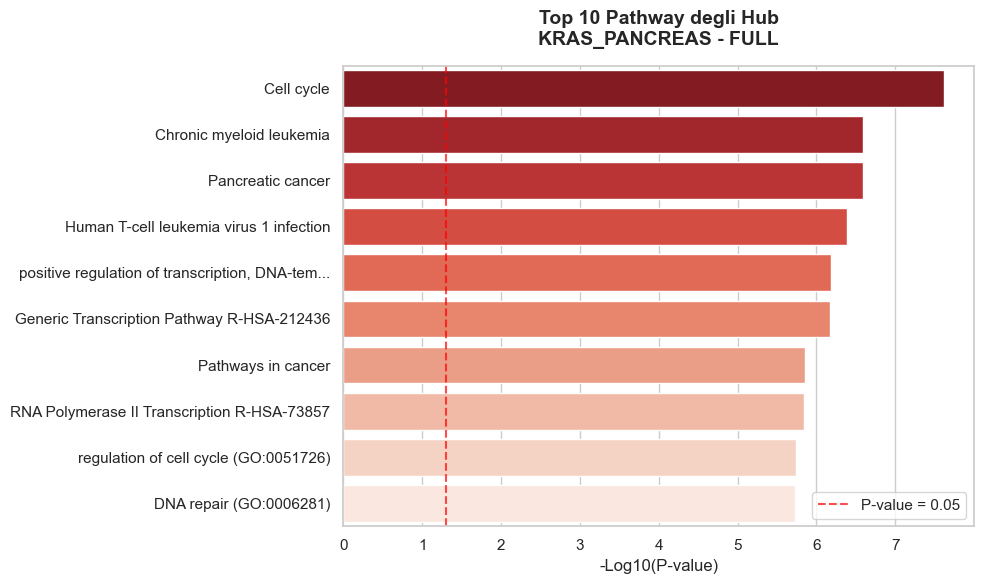

📊 Generazione grafico enrichment per: KRAS_LUNG (FULL)...


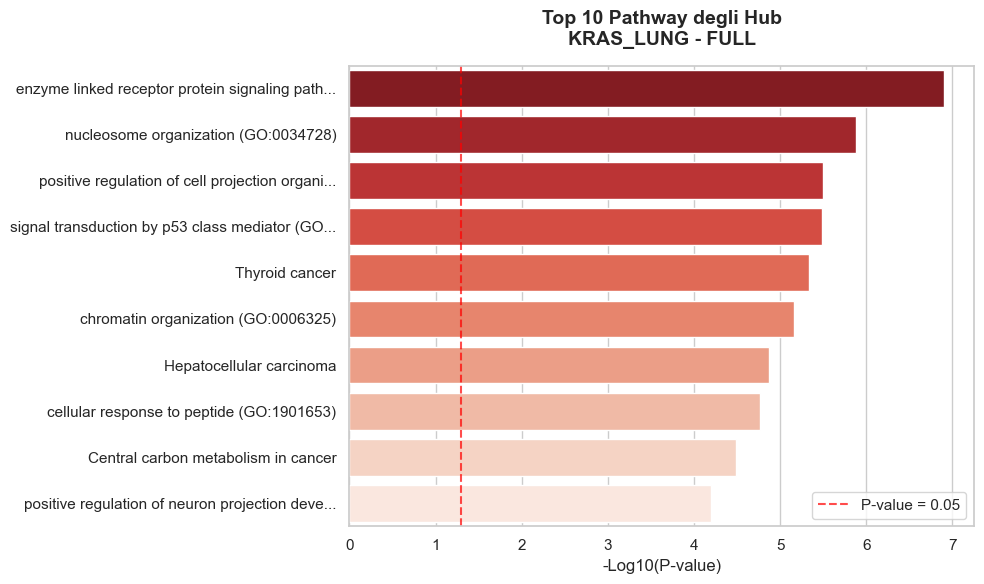

📊 Generazione grafico enrichment per: KRAS_COLON (FULL)...


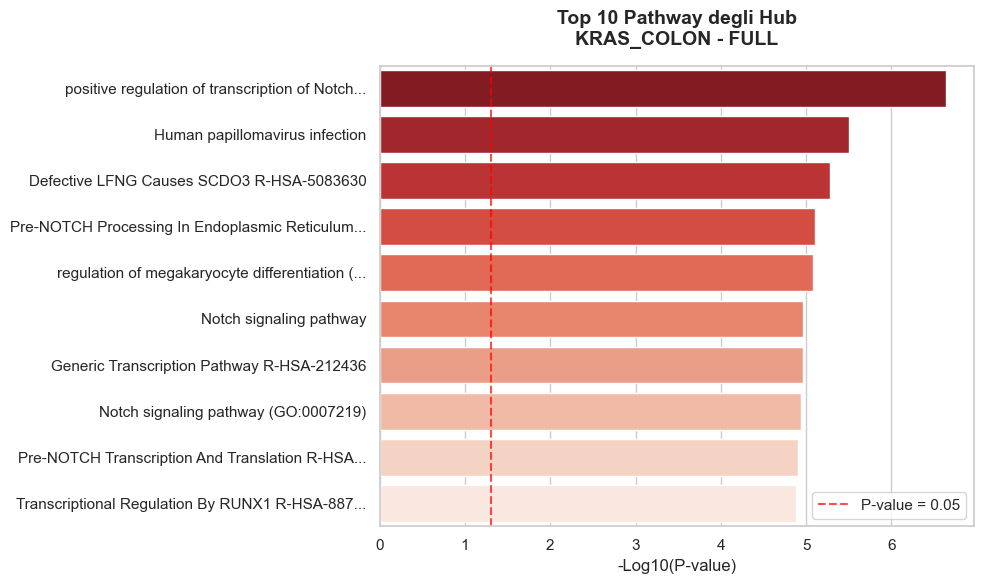

📊 Generazione grafico enrichment per: PANCREAS (FULL)...


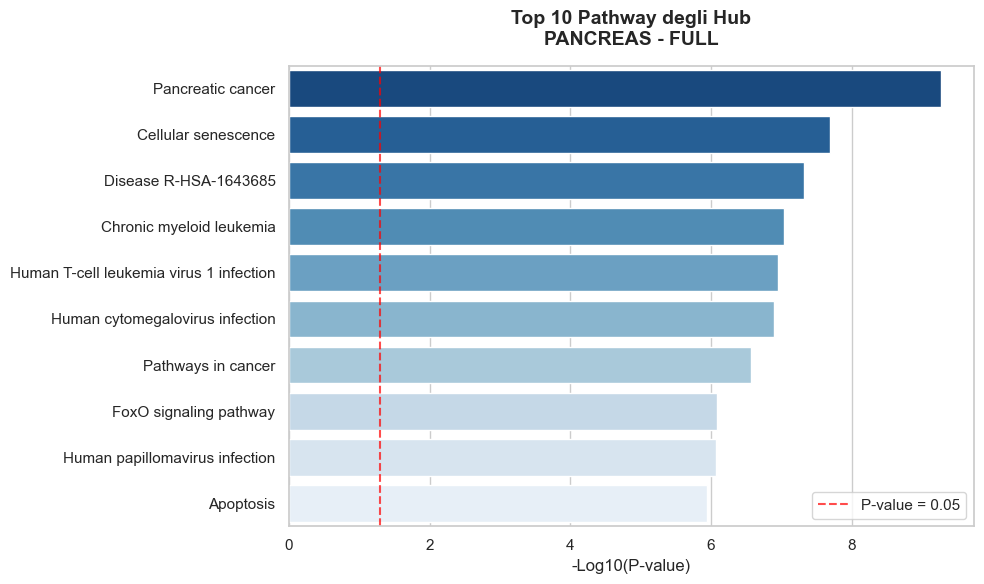

📊 Generazione grafico enrichment per: PANCREAS (FILTERED)...


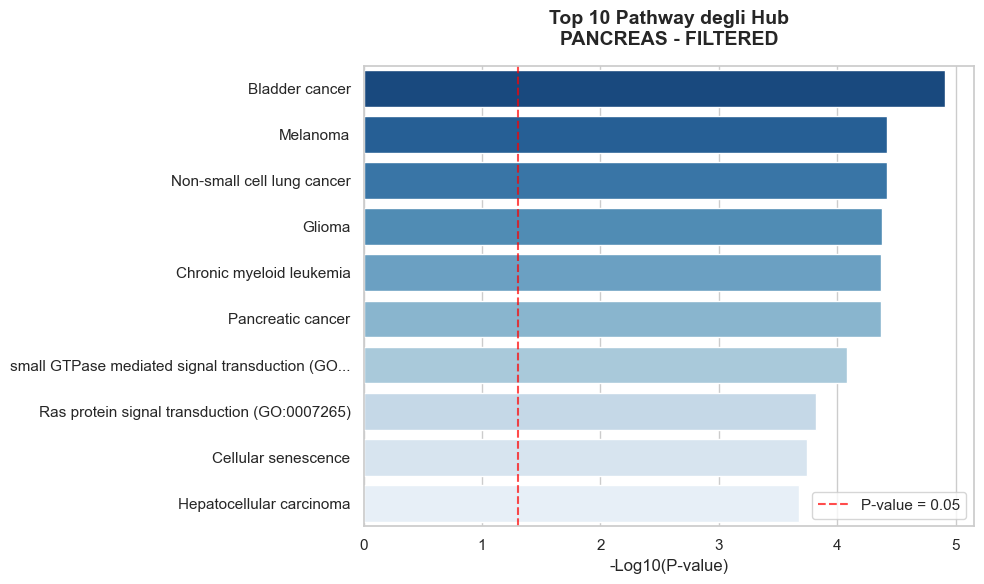

📊 Generazione grafico enrichment per: LUNG (FULL)...


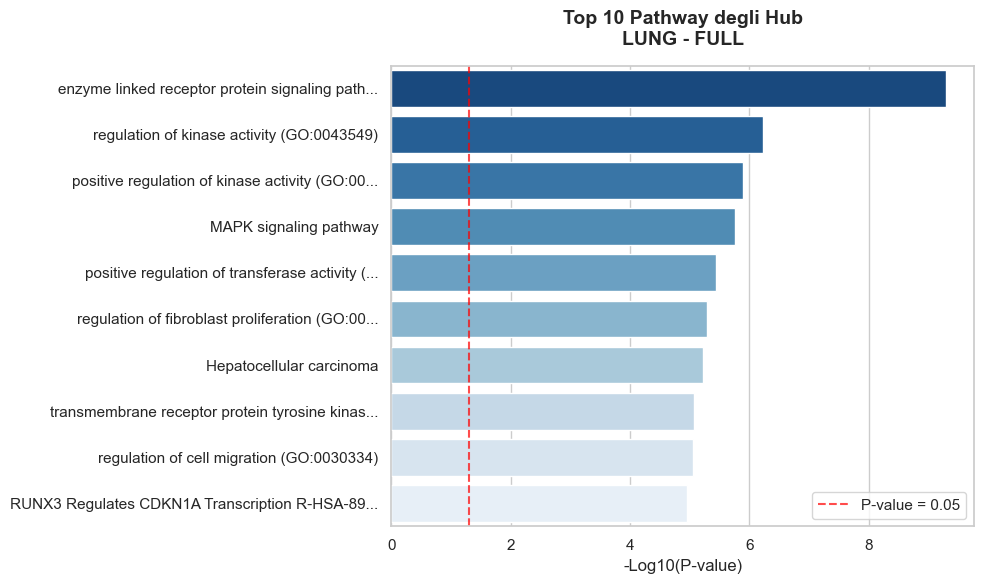

📊 Generazione grafico enrichment per: LUNG (FILTERED)...


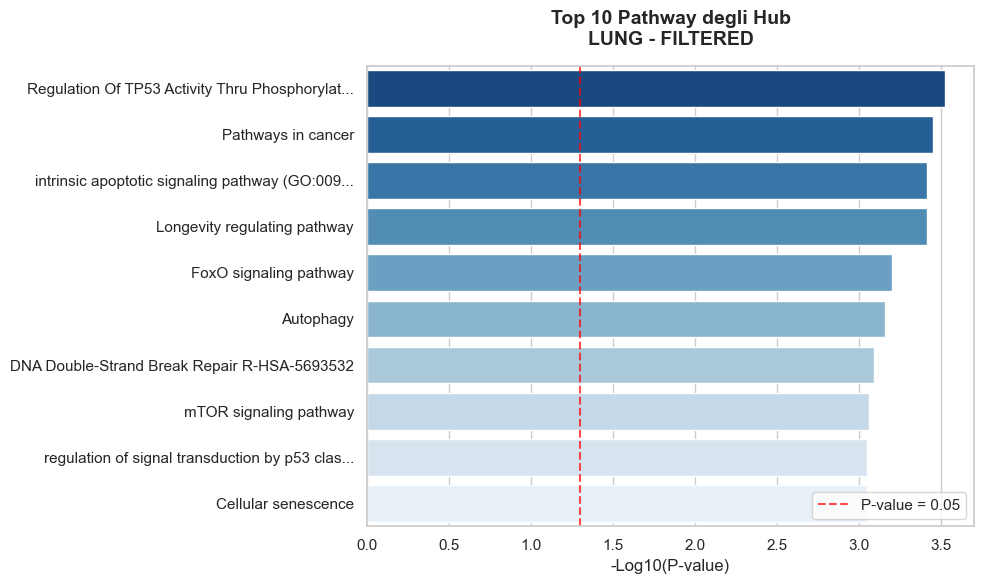

📊 Generazione grafico enrichment per: COLON (FULL)...


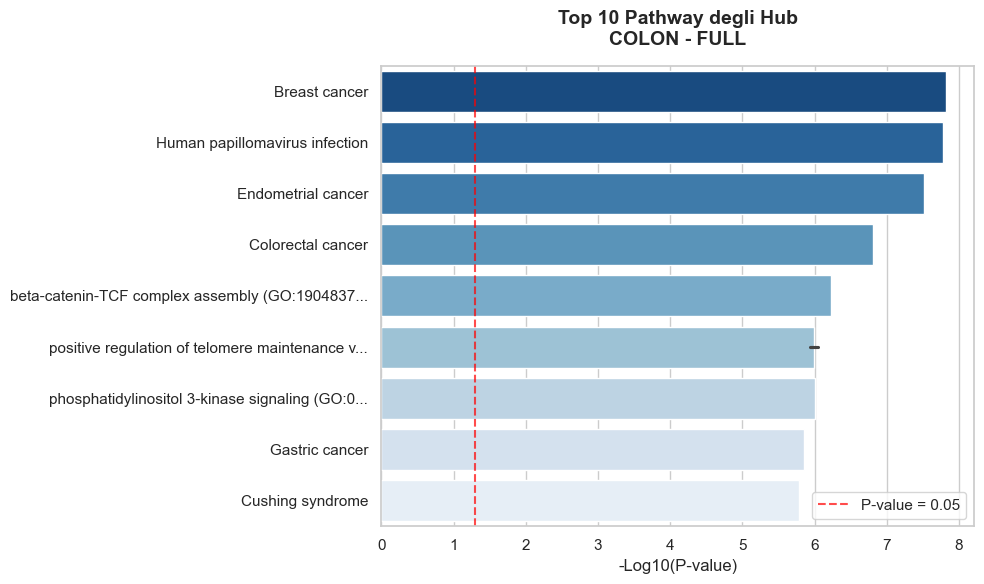

📊 Generazione grafico enrichment per: COLON (FILTERED)...


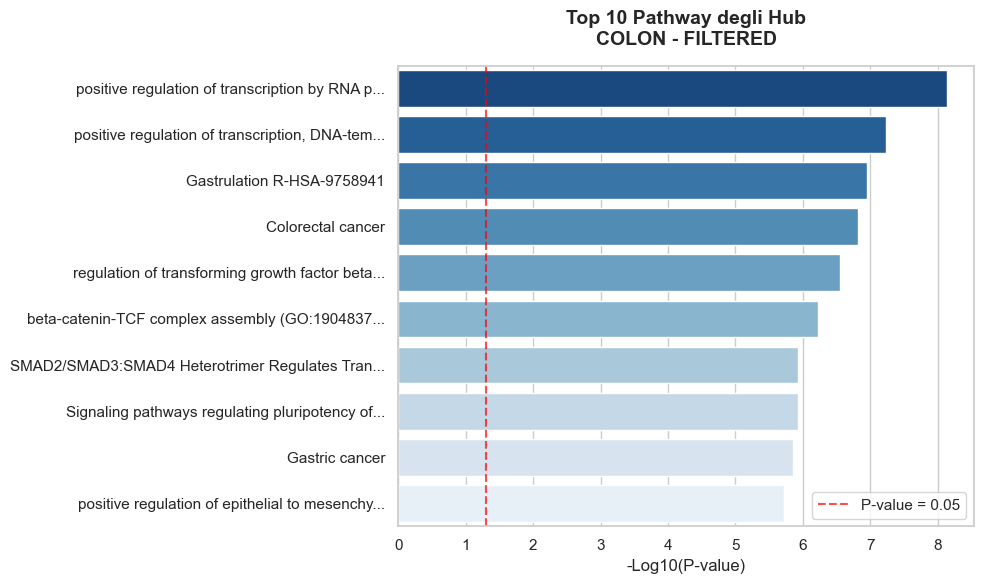


🎉 TUTTI I GRAFICI SONO STATI GENERATI E SALVATI NELLA CARTELLA 'plots'!


In [6]:
# ==========================================
# CELLA 11: VISUALIZZAZIONE GRAFICA DELL'ENRICHMENT DEGLI HUB
# ==========================================

def plot_hub_enrichment(cohort_name, target_gene, is_full=True):
    net_type = "FULL" if is_full else f"FILTERED"
    
    # 1. Percorsi file e cartelle
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    enrichment_file = f"{base_dir}/intracluster/Hubs_Global_Enrichment_{net_type}_{cohort_name}.tsv"
    
    # Creiamo una cartella dedicata per i grafici se non esiste
    plot_dir = f"{base_dir}/plots"
    os.makedirs(plot_dir, exist_ok=True)

    if not os.path.exists(enrichment_file):
        return # Esce silenziosamente se il file non esiste (es. nessun enrichment significativo)

    df_enr = pd.read_csv(enrichment_file, sep='\t')
    
    if df_enr.empty:
        return
        
    print(f"📊 Generazione grafico enrichment per: {cohort_name.upper()} ({net_type})...")

    # 2. Preparazione dei dati (Top 10 Pathway)
    # Ordiniamo per P-value e prendiamo i primi 10
    top_10 = df_enr.sort_values('P-value').head(10).copy()
    
    # Calcoliamo il -log10 del P-value (standard scientifico per questi grafici)
    top_10['Minus_Log10_Pval'] = -np.log10(top_10['P-value'])
    
    # Pulizia dei nomi troppo lunghi per il grafico
    top_10['Term'] = top_10['Term'].apply(lambda x: (x[:45] + '...') if len(x) > 45 else x)

    # 3. Creazione del grafico con Seaborn
    plt.figure(figsize=(10, 6))
    
    # Usiamo una palette di colori diversa a seconda del tipo di rete
    palette_color = "Reds_r" if "FILTRATA" in net_type or "kras_" in cohort_name else "Blues_r"
    
    ax = sns.barplot(
        x='Minus_Log10_Pval', 
        y='Term', 
        data=top_10, 
        palette=palette_color,
        hue='Term',
        legend=False
    )

    # Personalizzazione estetica
    titolo_grafico = f"Top 10 Pathway degli Hub\n{cohort_name.upper()} - {net_type}"
    plt.title(titolo_grafico, fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('-Log10(P-value)', fontsize=12)
    plt.ylabel('') # Rimuoviamo l'etichetta dell'asse Y perché i nomi dei pathway bastano
    
    # Aggiungiamo una linea rossa tratteggiata per la soglia di significatività (P-value = 0.05 -> -log10 = 1.3)
    plt.axvline(x=1.3, color='red', linestyle='--', alpha=0.7, label='P-value = 0.05')
    plt.legend(loc='lower right')

    plt.tight_layout()

    # 4. Salvataggio del grafico in alta risoluzione
    out_plot_png = f"{plot_dir}/Barplot_Hub_Enrichment_{net_type}_{cohort_name}.png"
    plt.savefig(out_plot_png, dpi=300, bbox_inches='tight')
    
    # Mostriamo il grafico a schermo dentro Jupyter
    plt.show()
    plt.close()


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI
# ==========================================
print("\n" + "="*80)
print("🎨 AVVIO GENERAZIONE GRAFICI DI ENRICHMENT")
print("="*80)

list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    if cohort.startswith('kras_'):
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=True)
    else:
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=True)
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=False)

print("\n🎉 TUTTI I GRAFICI SONO STATI GENERATI E SALVATI NELLA CARTELLA 'plots'!")

# ENRICHMENT PER OGNI CLUSTER


In [20]:
# ==========================================
# CELLA: ENRICHMENT ANALYSIS AUTOMATICA CON GSEAPY E SALVATAGGIO REPORT
# ==========================================

def run_cluster_enrichment(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per il nome dei file e dei titoli
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n--- 🧬 AVVIO ENRICHMENT AUTOMATICO: {cohort_name.upper()} ({net_type}) ---")
    
    # 1. Trova il file dei cluster generato in precedenza
    cluster_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    cluster_file = f"{cluster_dir}/Cluster_Genes_{net_type}_{cohort_name}.tsv"
    
    if not os.path.exists(cluster_file):
        print(f"[!] File cluster non trovato: {cluster_file}")
        return
        
    df_clusters = pd.read_csv(cluster_file, sep='\t', low_memory=False)
    
    # ---------------------------------------------------------
    # AUTO-DISCOVERY DEI DATABASE AGGIORNATI
    # ---------------------------------------------------------
    # Chiediamo al server di Enrichr la lista di TUTTI i database attivi oggi
    available_libs = gp.get_library_name(organism='human')
    
    # Filtriamo tutte le versioni di Reactome presenti e prendiamo la più recente (l'ultima della lista ordinata)
    reactome_versions = sorted([lib for lib in available_libs if 'Reactome' in lib])
    latest_reactome = reactome_versions[-1] if reactome_versions else 'Reactome_2016'
    
    print(f"[*] Auto-detect Reactome completato: userò '{latest_reactome}'")
    
    # Database biologici aggiornati
    databases = [
        'KEGG_2021_Human', 
        'GO_Biological_Process_2021', 
        'GO_Cellular_Component_2021', 
        'GO_Molecular_Function_2021',
        latest_reactome
    ]
    
    all_results = []
    cluster_ids = df_clusters['Cluster_ID'].unique()
    
    for c_id in cluster_ids:
        genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        # Saltiamo i cluster troppo piccoli (l'enrichment richiede un minimo di geni)
        if len(genes) < 4:
            continue
            
        print(f"Analizzo Cluster {c_id} ({len(genes)} geni)...")
        
        try:
            # Interroghiamo Enrichr
            enr = gp.enrichr(gene_list=genes, gene_sets=databases, organism='human', outdir=None) 
            res_df = enr.results
            sig_res = res_df[res_df['P-value'] < 0.05].copy()
            
            if not sig_res.empty:
                sig_res['Cluster_ID'] = c_id
                all_results.append(sig_res)
                
            # Piccola pausa per non farci bloccare dal server di Enrichr per troppe richieste
            time.sleep(1)
        except Exception as e:
            print(f"Errore nel Cluster {c_id}: {e}")
            
    # 4. SALVATAGGIO DATI COMPLETI E REPORT TESTUALE
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        cols = ['Cluster_ID', 'Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']
        final_df = final_df[cols].sort_values(by=['Cluster_ID', 'P-value'], ascending=[True, True])
        
        # Salva la tabella Excel/TSV completa (per eventuali grafici futuri)
        out_file_tsv = f"{cluster_dir}/Enrichment_Results_{net_type}_{cohort_name}.tsv"
        final_df.to_csv(out_file_tsv, sep='\t', index=False)
        print(f"✅ Analisi completata! Tabella dati salvata in: {out_file_tsv}")
        
        # --- CREAZIONE DEL FILE DI TESTO (REPORT PER IL PROF) ---
        out_file_txt = f"{cluster_dir}/Report_Prof_Top3_Enrichment_{net_type}_{cohort_name}.txt"
        
        # Apriamo il file in modalità scrittura ('w')
        with open(out_file_txt, 'w', encoding='utf-8') as f:
            
            titolo = f"--- 🏆 TOP 3 PATHWAY/ONTOLOGY PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
            print(f"\n{titolo}")
            f.write(f"{titolo}\n")
            
            for c_id in final_df['Cluster_ID'].unique():
                cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
                genes_str = ", ".join(cluster_genes)
                
                # Prepariamo le stringhe per l'intestazione del cluster
                sep = "="*80
                head1 = f"🎯 CLUSTER {c_id}  |  DIMENSIONE: {len(cluster_genes)} geni"
                head2 = f"🧬 TUTTI I GENI: {genes_str}"
                
                # Stampiamo a video
                print(f"\n{sep}\n{head1}\n{head2}\n{sep}")
                # Scriviamo nel file
                f.write(f"\n{sep}\n{head1}\n{head2}\n{sep}\n")
                
                top_3 = final_df[final_df['Cluster_ID'] == c_id].head(3)
                
                for index, row in top_3.iterrows():
                    # Prepariamo le stringhe per i pathway
                    path_title = f"🔸 [{row['Gene_set']}] {row['Term']}"
                    path_stats = f"   P-value: {row['P-value']:.2e}  |  Overlap: {row['Overlap']}"
                    path_genes = f"   🎯 Geni nel pathway: {row['Genes']}"
                    
                    # Stampiamo a video
                    print(f"\n{path_title}\n{path_stats}\n{path_genes}")
                    # Scriviamo nel file
                    f.write(f"\n{path_title}\n{path_stats}\n{path_genes}\n")
                    
        print(f"\n📄 REPORT DI TESTO PER IL PROF SALVATO IN: {out_file_txt}\n")
            
    else:
        print("[-] Nessun pathway significativo trovato per questi cluster.\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        # Rete 3: Mappa globale dei soli pazienti mutati
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        # Rete 1: Mappa globale di tutti i pazienti
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True)
        
        # Rete 2: Zoom specifico su KRAS
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=False)

print("\n🎉 TUTTE LE ANALISI DI ENRICHMENT SONO STATE COMPLETATE CON SUCCESSO!")


--- 🧬 AVVIO ENRICHMENT AUTOMATICO: KRAS_PANCREAS (FULL) ---
[*] Auto-detect Reactome completato: userò 'Reactome_Pathways_2024'
Analizzo Cluster 0 (16 geni)...
Analizzo Cluster 1 (13 geni)...
Analizzo Cluster 2 (14 geni)...
Analizzo Cluster 3 (8 geni)...
Analizzo Cluster 5 (16 geni)...
✅ Analisi completata! Tabella dati salvata in: ./outputs_mut/kras_pancreas/networks/Enrichment_Results_FULL_kras_pancreas.tsv

--- 🏆 TOP 3 PATHWAY/ONTOLOGY PER OGNI CLUSTER (KRAS_PANCREAS - FULL) ---

🎯 CLUSTER 0  |  DIMENSIONE: 16 geni
🧬 TUTTI I GENI: ARID1A, AXIN1, BRCA1, BRCA2, CCND2, FAT1, FLT1, INSR, KMT2C, KMT2D, MAP2K4, POLE, PTPRD, RPTOR, SMAD2, SMARCA4

🔸 [Reactome_Pathways_2024] Transcriptional Regulation by RUNX1
   P-value: 7.25e-09  |  Overlap: 6/202
   🎯 Geni nel pathway: KMT2D;CCND2;KMT2C;AXIN1;ARID1A;SMARCA4

🔸 [GO_Biological_Process_2021] positive regulation of transcription, DNA-templated (GO:0045893)
   P-value: 6.74e-08  |  Overlap: 9/1183
   🎯 Geni nel pathway: SMAD2;RPTOR;KMT2D;KMT

# ENRICHMENT DEGLI HUB PER OGNI SINGOLO CLUSTER
Analizza specificamente i top Hub locali di ciascuna comunità.

In [8]:
# ==========================================
# CELLA: ENRICHMENT HUB SPECIFICI PER CLUSTER
# ==========================================

def enrich_cluster_hubs(cohort_name, target_gene, is_full=True):
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/intracluster"
    centrality_file = f"{base_dir}/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(centrality_file):
        print(f"[!] File centralità non trovato per {cohort_name}. Esegui prima l'Intracluster.")
        return

    df_centrality = pd.read_csv(centrality_file, sep='\t')
    databases = ['KEGG_2021_Human', 'GO_Biological_Process_2021', 'Reactome_2022']
    
    out_txt = f"{base_dir}/Report_Prof_Cluster_Specific_Hub_Pathways_{net_type}_{cohort_name}.txt"
    with open(out_txt, 'w', encoding='utf-8') as f:
        titolo = f"--- 🏆 ENRICHMENT HUB LOCALI PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
        f.write(f"{titolo}\n\n")
        
        for c_id in df_centrality['Cluster_ID'].unique():
            cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
            top_hubs = cluster_df.head(5)['Gene'].tolist() # Prendiamo i top 5 hub locali
            
            f.write(f"================================================================================\n")
            f.write(f"🎯 CLUSTER {c_id}  |  TOP HUB ANALIZZATI: {len(top_hubs)}\n")
            f.write(f"🧬 GENI HUB: {', '.join(top_hubs)}\n")
            f.write(f"================================================================================\n\n")
            
            if len(top_hubs) < 2:
                f.write("[-] Troppi pochi hub per un enrichment.\n\n")
                print(f" Cluster {c_id}: Saltato (troppi pochi hub).")
                continue
                
            print(f" Analizzo Hub del Cluster {c_id}...")
            try:
                enr = gp.enrichr(gene_list=top_hubs, gene_sets=databases, organism='human', outdir=None)
                sig_res = enr.results[enr.results['P-value'] < 0.05].copy()
                time.sleep(1)
            except Exception as e:
                f.write(f"[-] Errore Enrichr per questo cluster.\n\n")
                continue
                
            if not sig_res.empty:
                sig_res = sig_res.sort_values(by=['P-value'], ascending=True)
                for index, row in sig_res.head(3).iterrows():
                    f.write(f"🔸 [{row['Gene_set']}] {row['Term']}\n")
                    f.write(f"   - P-value: {row['P-value']:.2e} | Overlap: {row['Overlap']}\n")
                    f.write(f"   - Geni nel pathway: {row['Genes']}\n\n")
            else:
                f.write("[-] Nessun pathway significativo trovato.\n\n")

    print(f"✅ Report salvato: {out_txt}")

for cohort in COORTI.keys():
    enrich_cluster_hubs(cohort, TARGET_GENE, is_full=True)
    if not cohort.startswith('kras_'):
        enrich_cluster_hubs(cohort, TARGET_GENE, is_full=False)



🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: KRAS_PANCREAS (FULL)
 Analizzo Hub del Cluster 0...
 Analizzo Hub del Cluster 1...
 Analizzo Hub del Cluster 2...
 Analizzo Hub del Cluster 3...
 Analizzo Hub del Cluster 5...
✅ Report salvato: ./outputs_mut/kras_pancreas/intracluster/Report_Prof_Cluster_Specific_Hub_Pathways_FULL_kras_pancreas.txt

🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: KRAS_LUNG (FULL)
 Analizzo Hub del Cluster 0...
 Analizzo Hub del Cluster 1...
 Analizzo Hub del Cluster 2...
 Analizzo Hub del Cluster 3...
 Analizzo Hub del Cluster 4...
 Analizzo Hub del Cluster 5...
✅ Report salvato: ./outputs_mut/kras_lung/intracluster/Report_Prof_Cluster_Specific_Hub_Pathways_FULL_kras_lung.txt

🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: KRAS_COLON (FULL)
 Analizzo Hub del Cluster 0...
 Analizzo Hub del Cluster 1...
 Analizzo Hub del Cluster 2...
 Analizzo Hub del Cluster 3...
 Analizzo Hub del Cluster 4...
✅ Report salvato: ./outputs_mut/kras_colon/intracluster/Report_Prof_Cluster_Specific_Hub_Pa

# ANALISI VARIE TECNICHE DI CLUSTERING



  🔬 CONFRONTO CLUSTERING — KRAS_PANCREAS
  Rete: 69 nodi, 99 archi

  ▶ Louvain... ✓  Q=0.573  k=6  sil=0.1191  (0.0s)

  ▶ Leiden... ✓  Q=0.570  k=6  sil=0.1165  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.551  k=7  sil=0.1287  (0.1s)

  ▶ Infomap... ✓  Q=0.547  k=10  sil=0.1768  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  6      0.5726      0.1191          1.0000       0.00
       Leiden  6      0.5695      0.1165          0.8803       0.00
Girvan-Newman  7      0.5512      0.1287          0.6789       0.14
      Infomap 10      0.5467      0.1768          0.8352       0.00
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_pancreas/networks/Clustering_Comparison_kras_pancreas.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


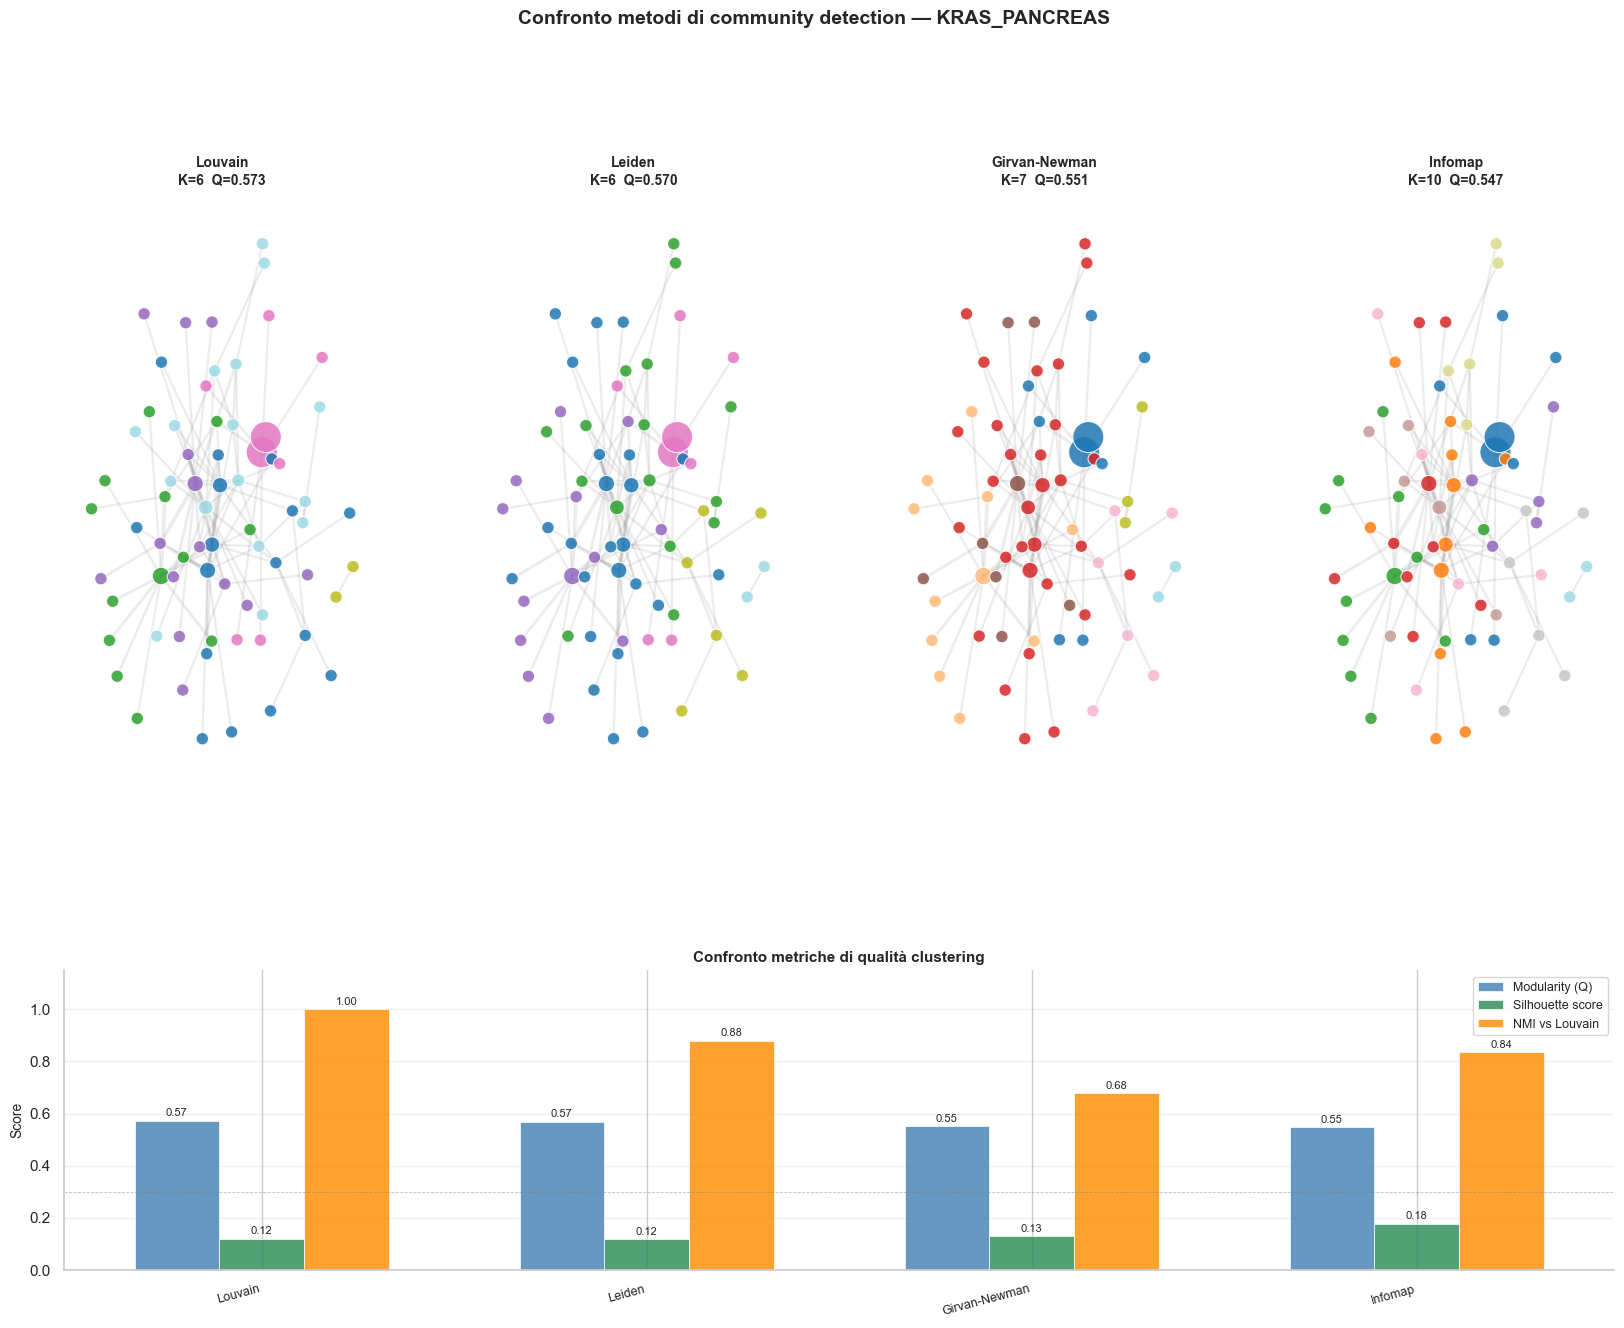

✅ Plot comparativo salvato: ./outputs_mut/kras_pancreas/networks/Clustering_Comparison_kras_pancreas.png

  🔬 CONFRONTO CLUSTERING — KRAS_LUNG
  Rete: 248 nodi, 899 archi

  ▶ Louvain... ✓  Q=0.346  k=6  sil=0.0368  (0.0s)

  ▶ Leiden... ✓  Q=0.353  k=8  sil=0.0499  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.012  k=3  sil=0.0277  (5.6s)

  ▶ Infomap... ✓  Q=0.257  k=9  sil=0.0362  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  6      0.3463      0.0368          1.0000       0.01
       Leiden  8      0.3528      0.0499          0.5267       0.00
Girvan-Newman  3      0.0120      0.0277          0.0597       5.57
      Infomap  9      0.2567      0.0362          0.4082       0.01
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_lung/networks/Clustering_Comparison_kras_lung.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


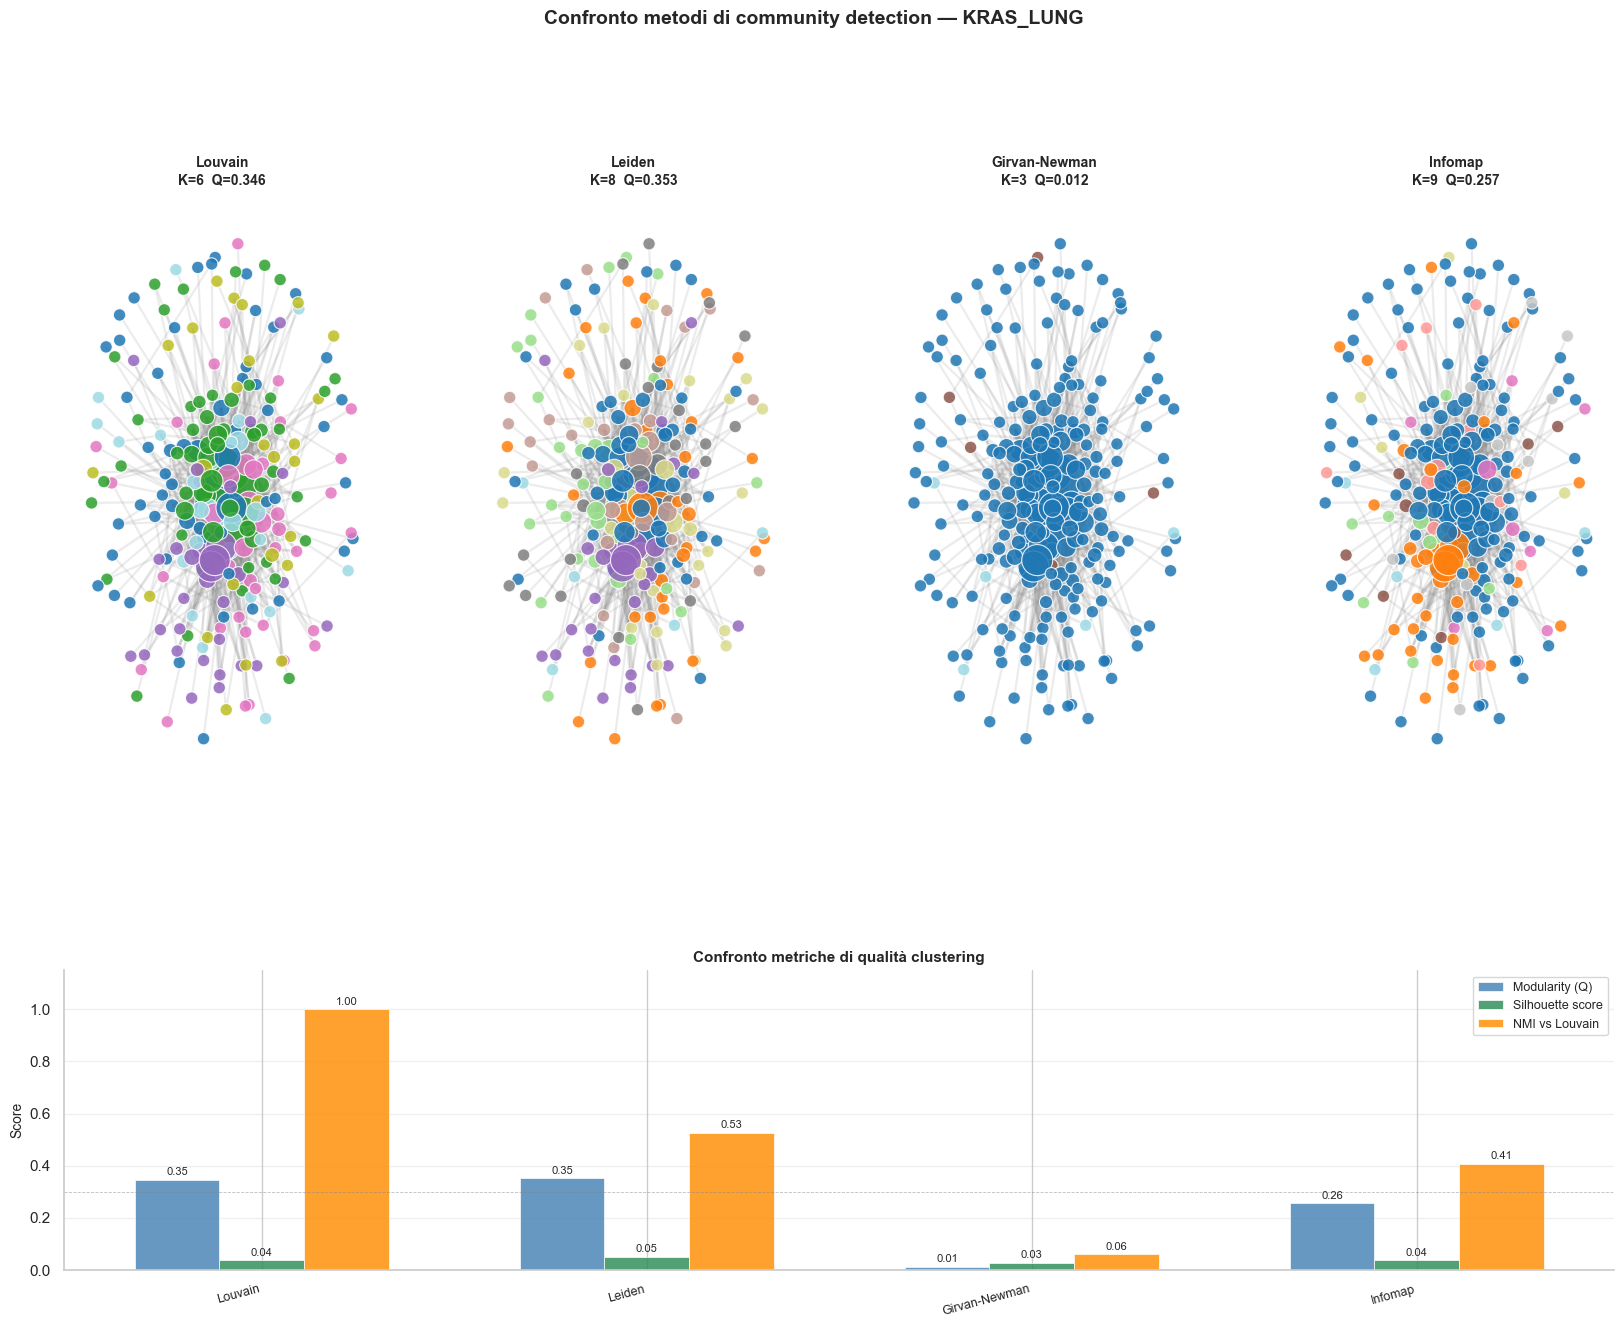

✅ Plot comparativo salvato: ./outputs_mut/kras_lung/networks/Clustering_Comparison_kras_lung.png

  🔬 CONFRONTO CLUSTERING — KRAS_COLON
  Rete: 280 nodi, 5855 archi

  ▶ Louvain... ✓  Q=0.156  k=5  sil=0.0698  (0.0s)

  ▶ Leiden... ✓  Q=0.157  k=5  sil=0.0732  (0.0s)

  ▶ Girvan-Newman... ✓  Q=-0.000  k=2  sil=0.1034  (10.9s)

  ▶ Infomap... ✓  Q=0.002  k=2  sil=0.0807  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  5      0.1562      0.0698          1.0000       0.04
       Leiden  5      0.1570      0.0732          0.6423       0.01
Girvan-Newman  2     -0.0000      0.1034          0.0066      10.94
      Infomap  2      0.0023      0.0807          0.0178       0.01
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_colon/networks/Clustering_Comparison_kras_colon.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


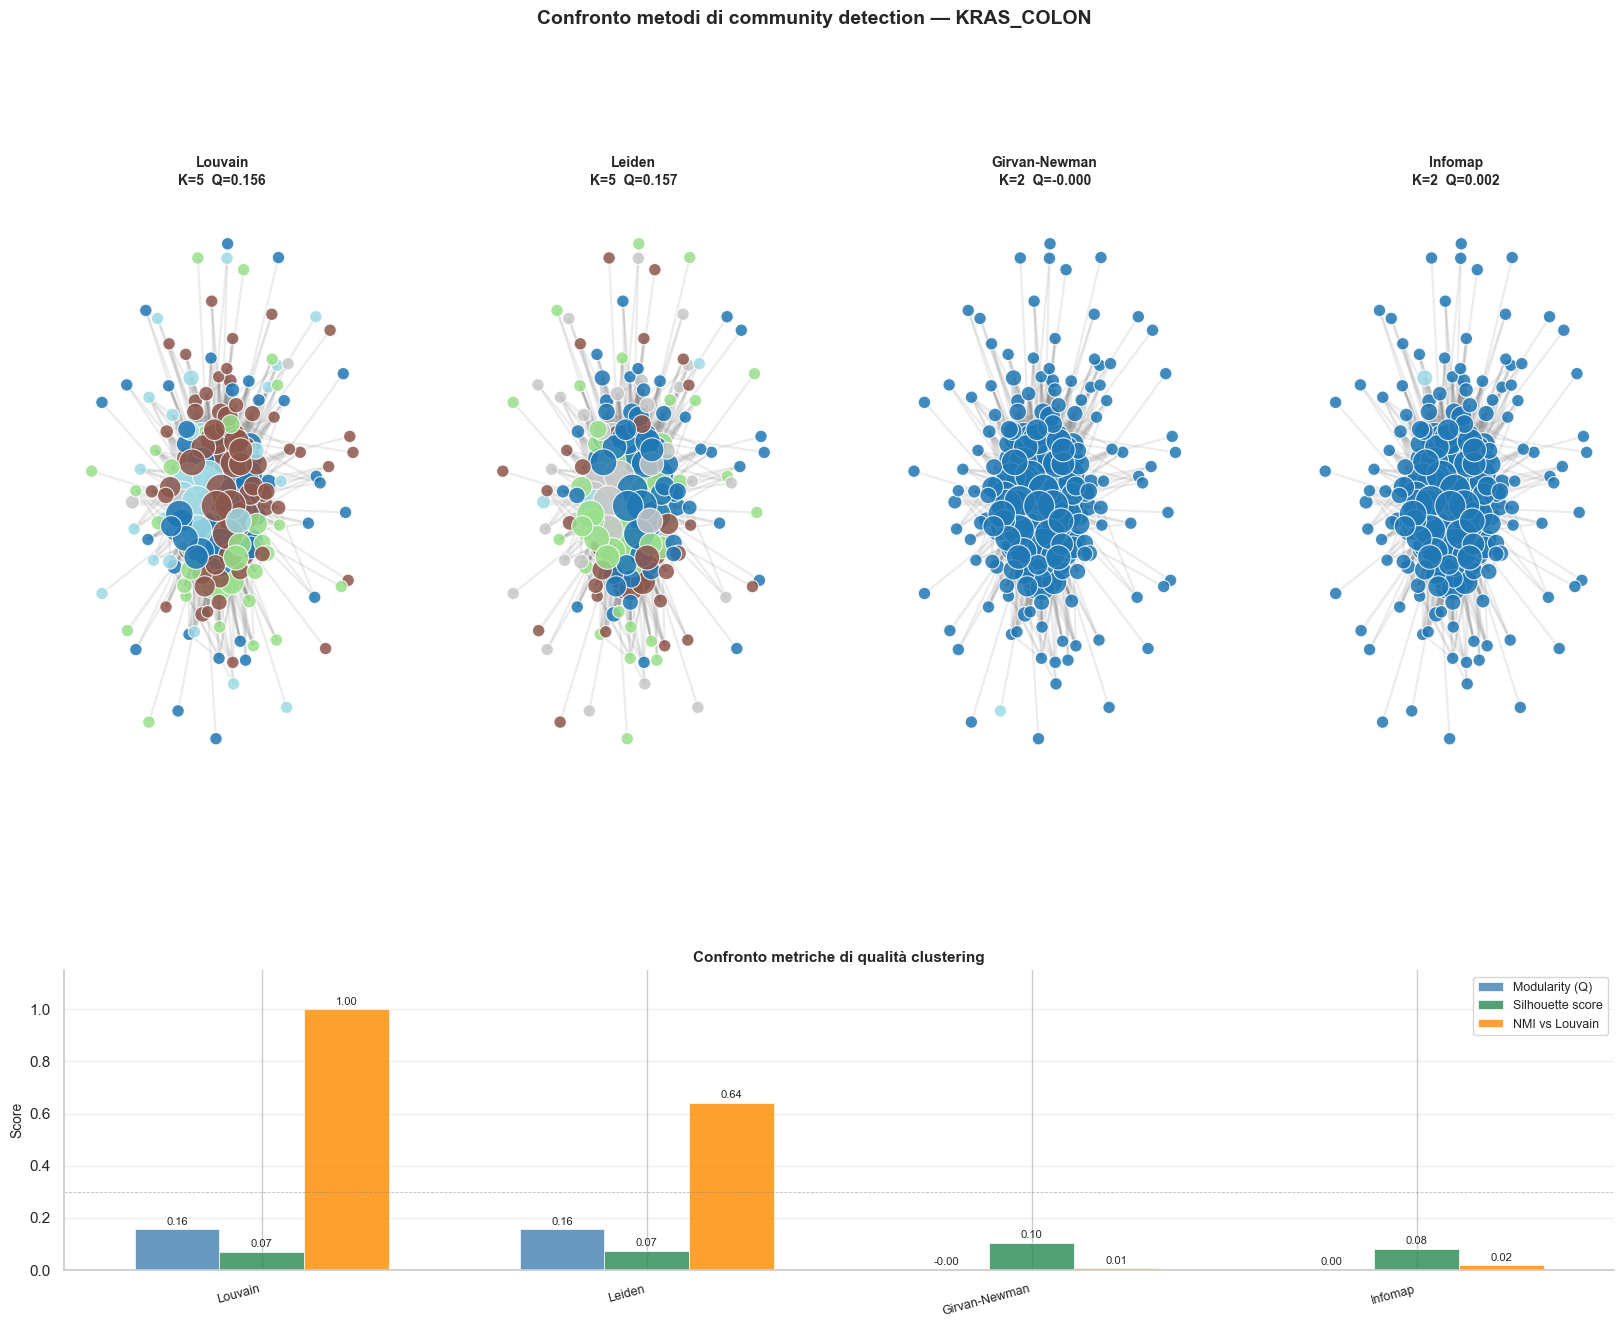

✅ Plot comparativo salvato: ./outputs_mut/kras_colon/networks/Clustering_Comparison_kras_colon.png

  🔬 CONFRONTO CLUSTERING — PANCREAS
  Rete: 101 nodi, 241 archi

  ▶ Louvain... ✓  Q=0.420  k=4  sil=0.0747  (0.0s)

  ▶ Leiden... ✓  Q=0.420  k=4  sil=0.0747  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.397  k=7  sil=0.0953  (0.5s)

  ▶ Infomap... ✓  Q=0.413  k=9  sil=0.1273  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  4      0.4202      0.0747          1.0000       0.00
       Leiden  4      0.4202      0.0747          1.0000       0.00
Girvan-Newman  7      0.3971      0.0953          0.7982       0.54
      Infomap  9      0.4130      0.1273          0.7977       0.00
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/pancreas/networks/Clustering_Comparison_pancreas.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


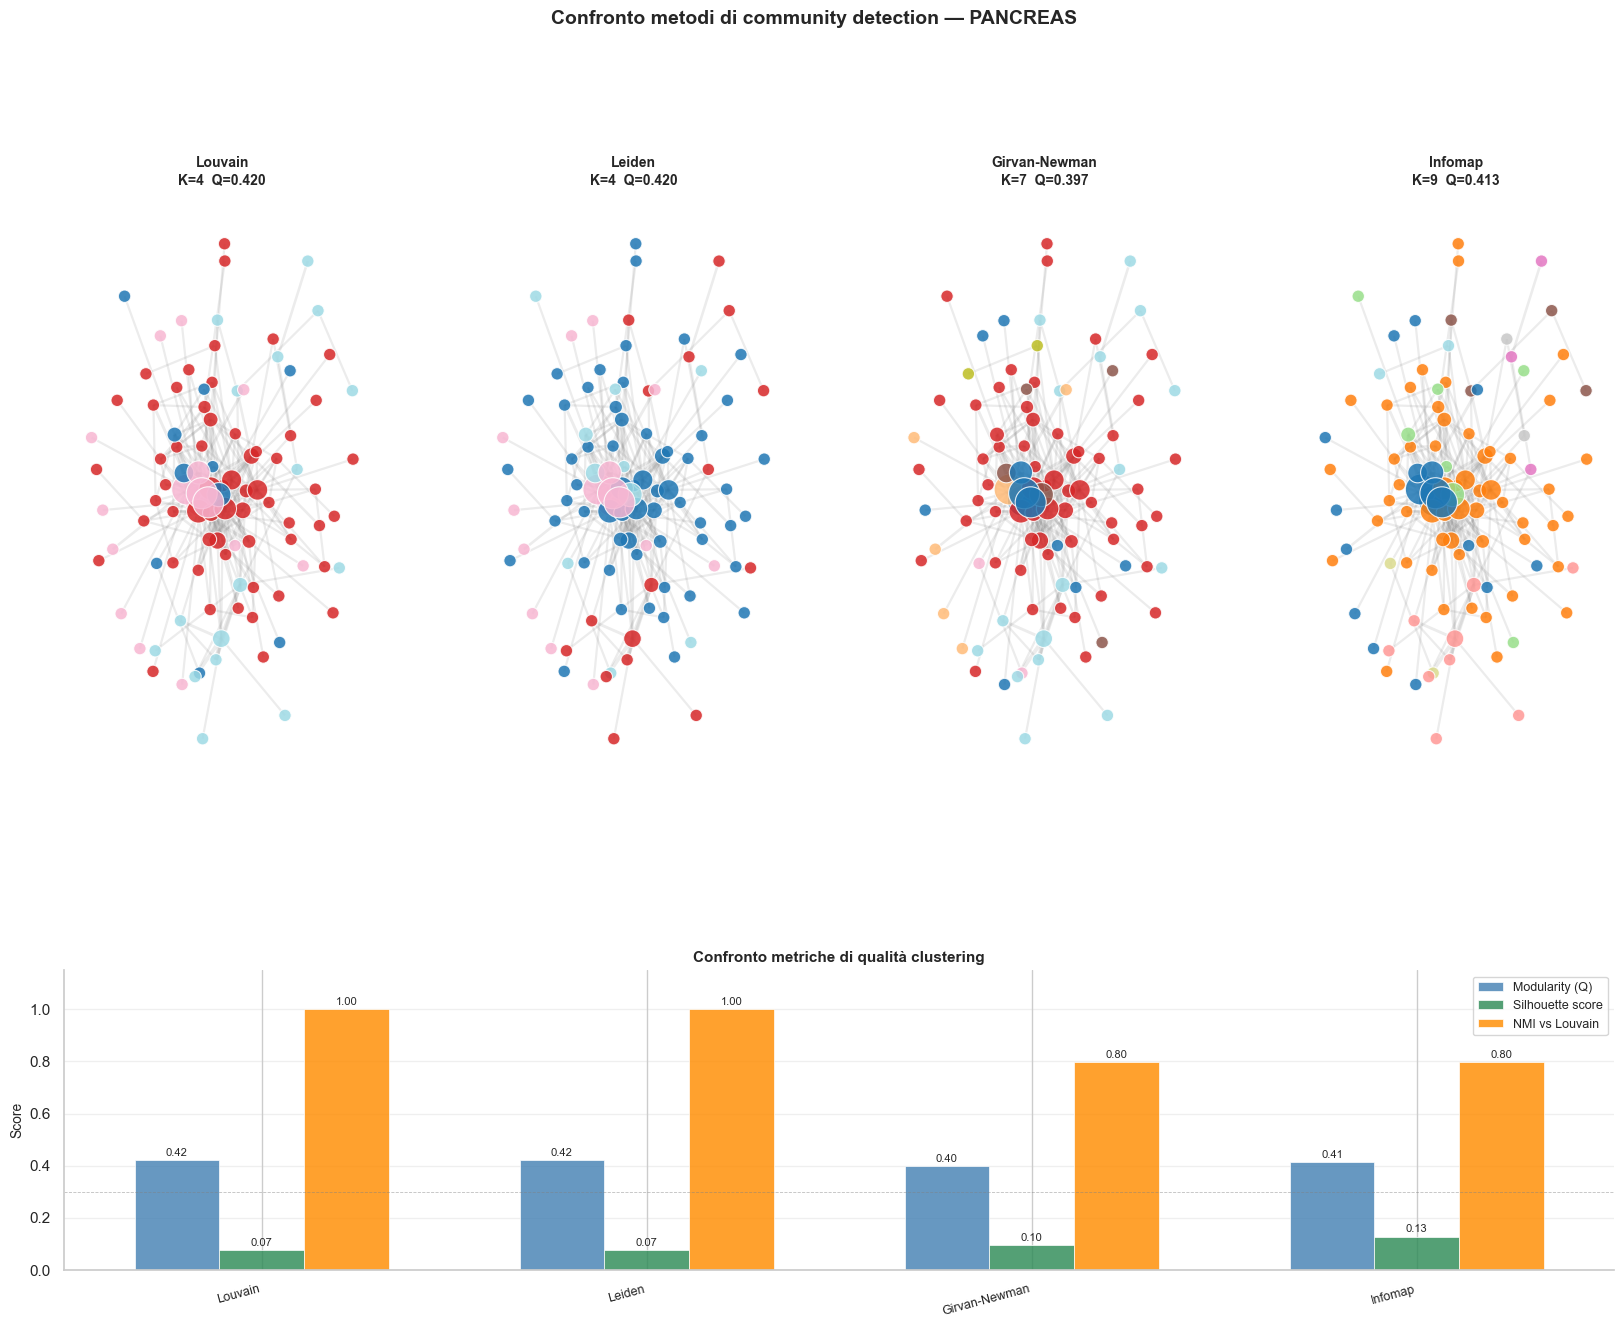

✅ Plot comparativo salvato: ./outputs_mut/pancreas/networks/Clustering_Comparison_pancreas.png

  🔬 CONFRONTO CLUSTERING — LUNG
  Rete: 437 nodi, 7018 archi

  ▶ Louvain... ✓  Q=0.140  k=5  sil=0.0286  (0.1s)

  ▶ Leiden... ✓  Q=0.141  k=6  sil=0.0203  (0.0s)

  ▶ Girvan-Newman... ✓  Q=-0.000  k=2  sil=0.0555  (20.9s)

  ▶ Infomap... ✓  Q=0.002  k=2  sil=0.0583  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  5      0.1402      0.0286          1.0000       0.05
       Leiden  6      0.1411      0.0203          0.3007       0.01
Girvan-Newman  2     -0.0000      0.0555          0.0043      20.88
      Infomap  2      0.0021      0.0583          0.0087       0.02
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/lung/networks/Clustering_Comparison_lung.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


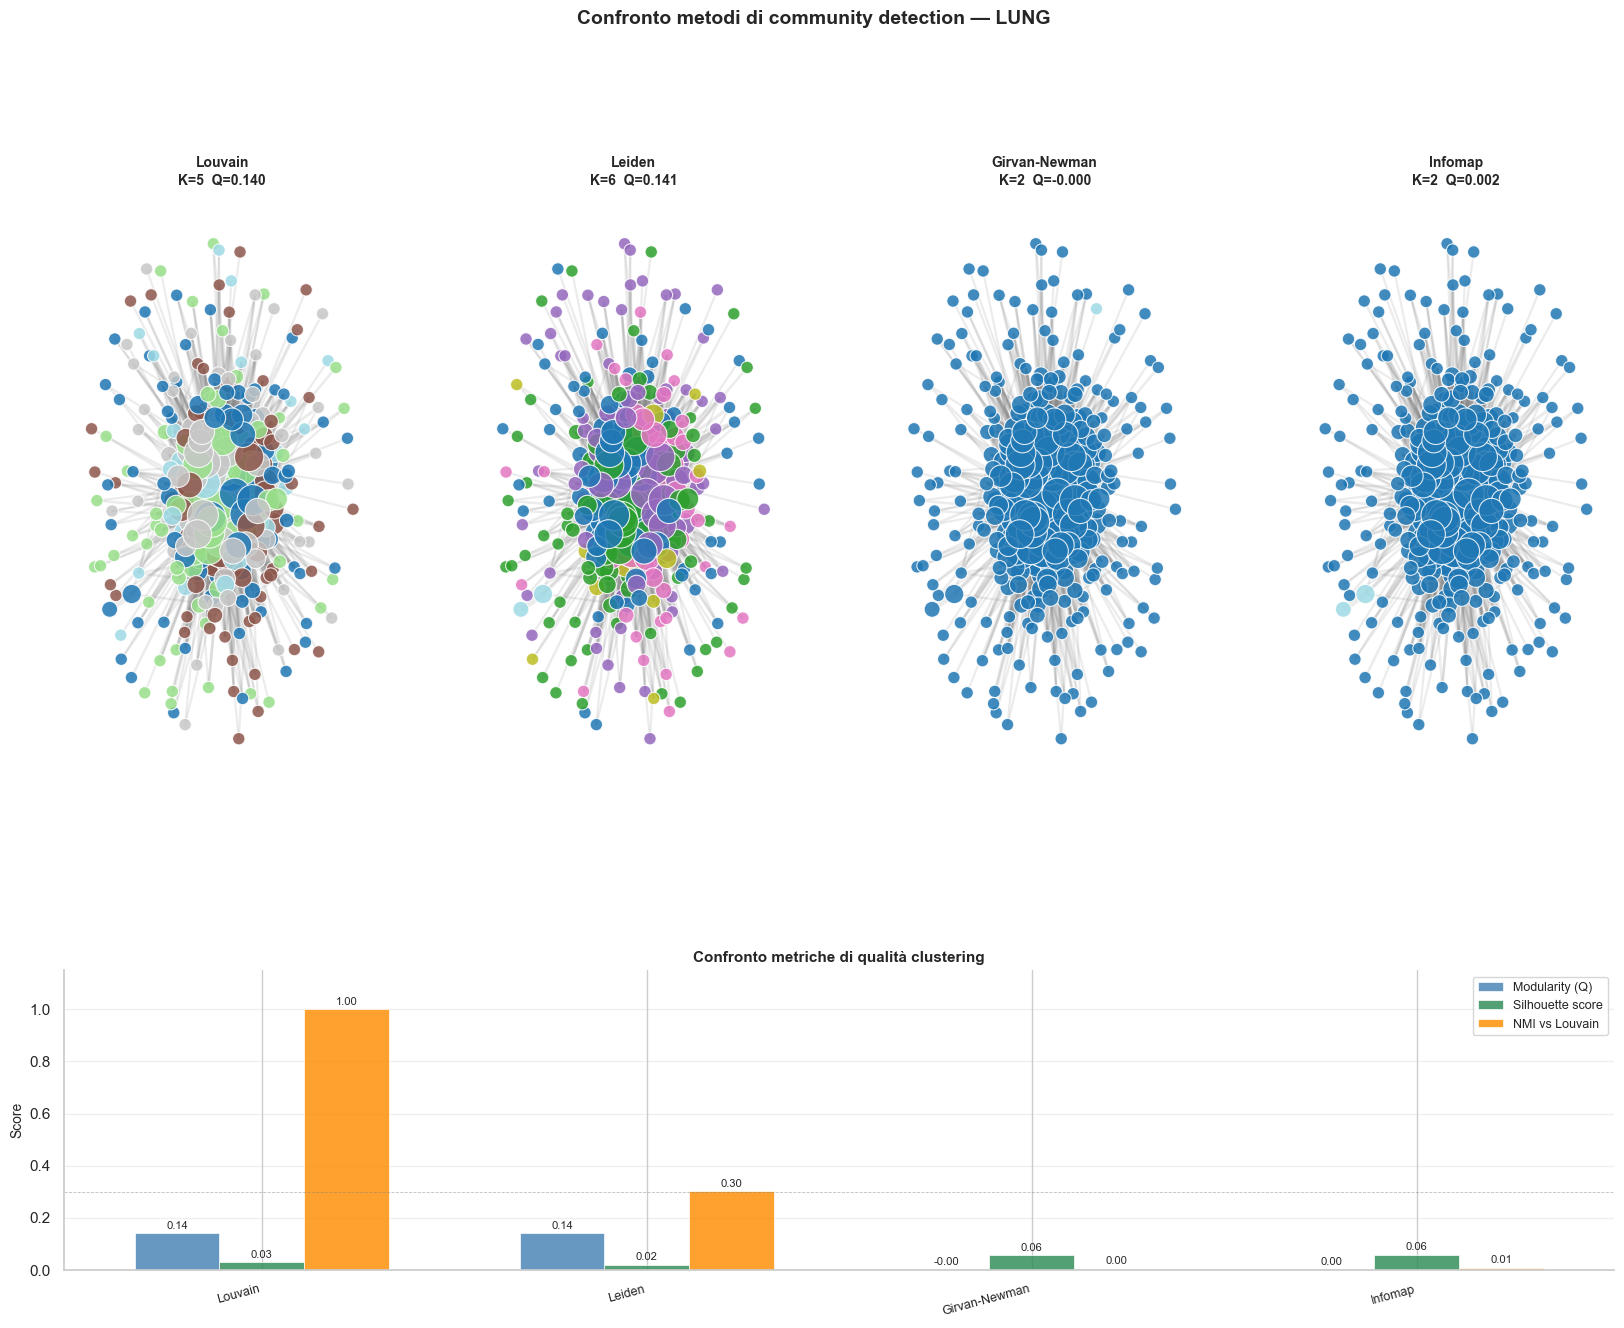

✅ Plot comparativo salvato: ./outputs_mut/lung/networks/Clustering_Comparison_lung.png

  🔬 CONFRONTO CLUSTERING — COLON
  Rete: 300 nodi, 6102 archi

  ▶ Louvain... ✓  Q=0.193  k=4  sil=0.0784  (0.0s)

  ▶ Leiden... ✓  Q=0.196  k=5  sil=0.0904  (0.0s)

  ▶ Girvan-Newman... ✓  Q=-0.000  k=2  sil=0.0923  (12.2s)

  ▶ Infomap... ✓  Q=0.000  k=2  sil=0.0951  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  4      0.1930      0.0784          1.0000       0.04
       Leiden  5      0.1958      0.0904          0.5833       0.01
Girvan-Newman  2     -0.0000      0.0923          0.0072      12.17
      Infomap  2      0.0003      0.0951          0.0143       0.02
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/colon/networks/Clustering_Comparison_colon.tsv


C:\Users\miche\AppData\Local\Temp\ipykernel_14924\504770425.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


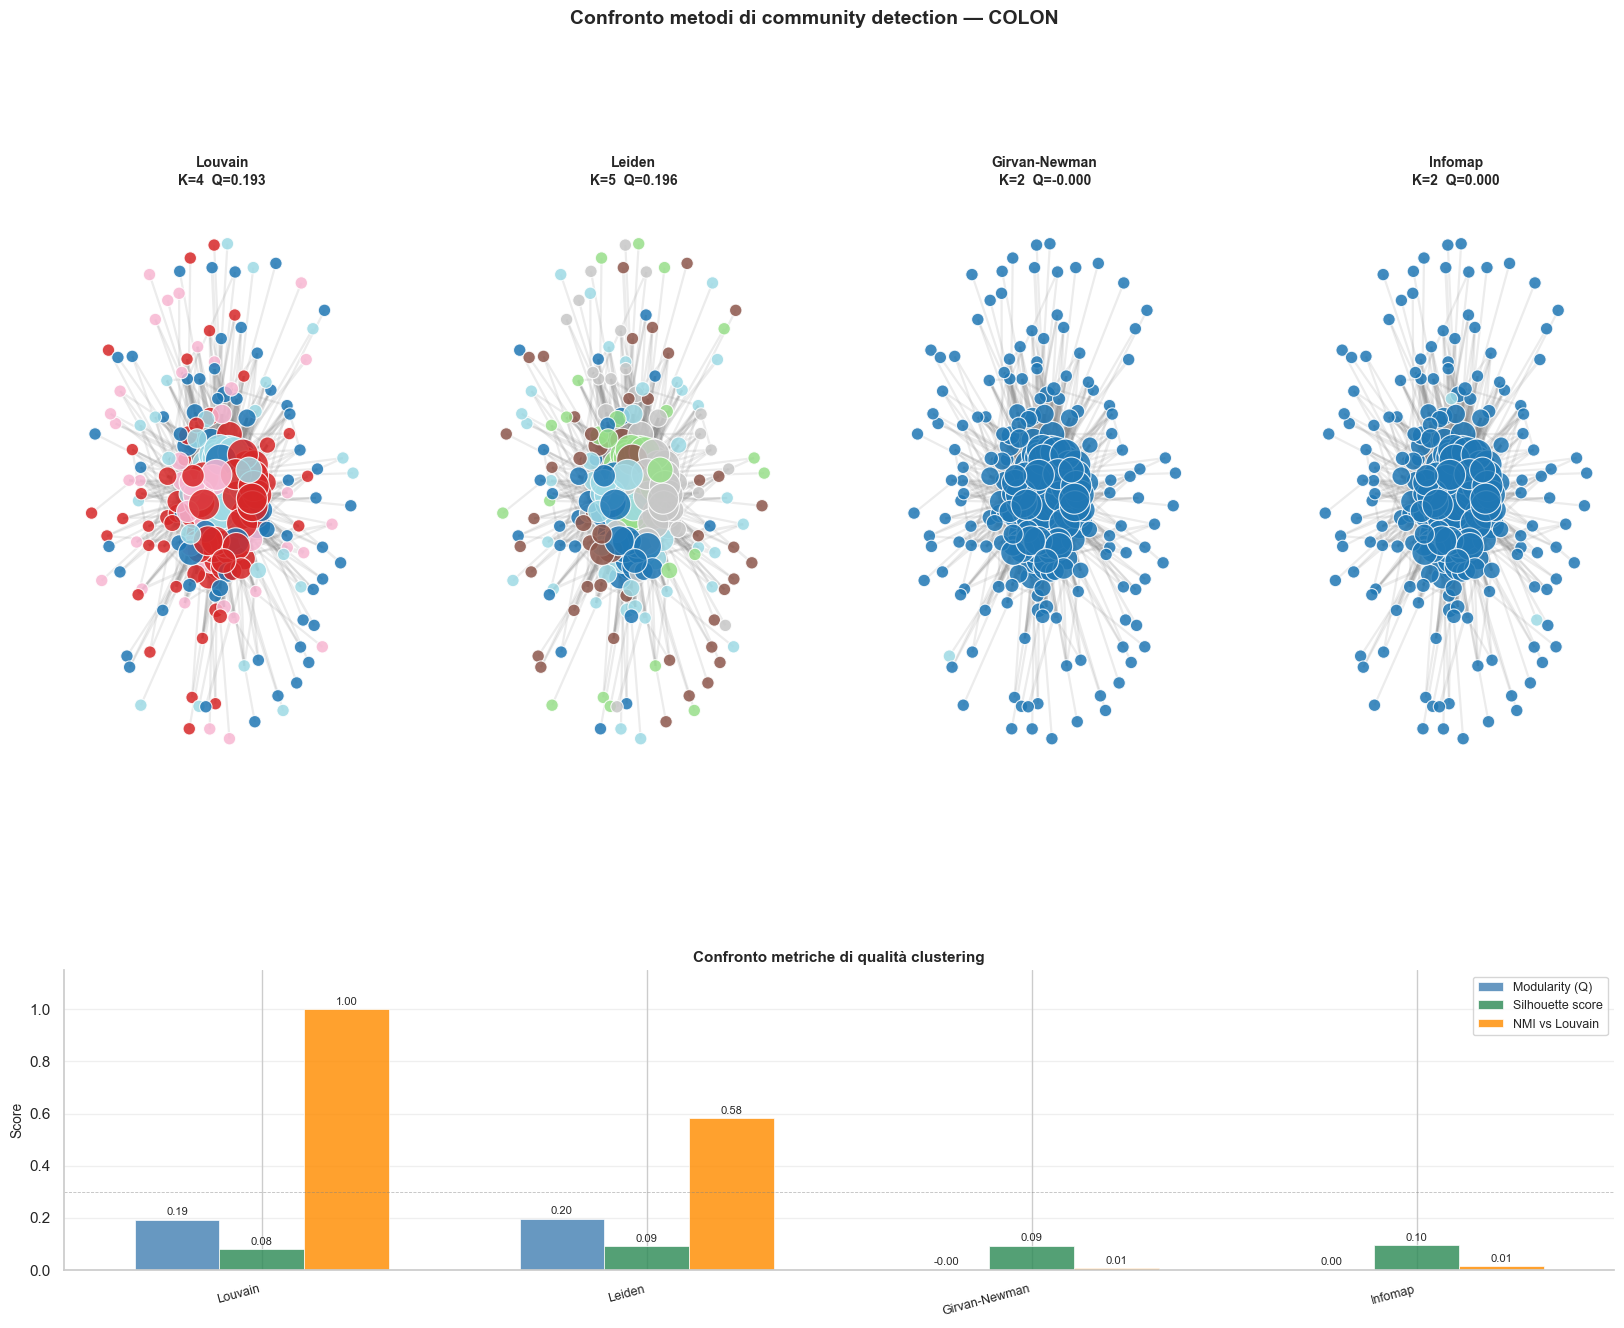

✅ Plot comparativo salvato: ./outputs_mut/colon/networks/Clustering_Comparison_colon.png

🏁 Confronto clustering completato per tutte le coorti.


In [9]:
# ==========================================
# CONFRONTO METODI DI CLUSTERING
# ==========================================

# --- Dipendenze opzionali ---
try:
    import leidenalg
    import igraph as ig
    LEIDEN_AVAILABLE = True
except ImportError:
    LEIDEN_AVAILABLE = False
    print("⚠️  Leiden non disponibile. Installa con: pip install leidenalg igraph")

try:
    import infomap as im_lib
    INFOMAP_AVAILABLE = True
except ImportError:
    INFOMAP_AVAILABLE = False
    print("⚠️  Infomap non disponibile. Installa con: pip install infomap")


# ─────────────────────────────────────────
# UTILITY: conversione networkx → igraph
# ─────────────────────────────────────────
def nx_to_igraph(G):
    """Converte un grafo NetworkX pesato in igraph (necessario per Leiden)."""
    nodes = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}
    edges = [(node_idx[u], node_idx[v]) for u, v in G.edges()]
    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g.es['weight'] = weights
    g.vs['name'] = nodes
    return g, nodes


# ─────────────────────────────────────────
# METODI DI CLUSTERING
# ─────────────────────────────────────────
def run_louvain(G):
    comms = nx_comm.louvain_communities(G, weight='weight', seed=42)
    return comms

def run_leiden(G):
    if not LEIDEN_AVAILABLE:
        return None
    g_ig, nodes = nx_to_igraph(G)
    partition = leidenalg.find_partition(
        g_ig,
        leidenalg.ModularityVertexPartition,
        weights='weight',
        seed=42
    )
    comms = [set(nodes[i] for i in part) for part in partition]
    return comms

def run_girvan_newman(G, max_communities=20):
    """
    Girvan-Newman: si ferma quando raggiunge il massimo di modularity
    o il numero di community target. Su reti grandi è lento: limitiamo
    l'esplorazione a max_communities step.
    """
    comp = nx_comm.girvan_newman(G)
    best_comms = None
    best_mod = -1
    for comms_tuple in comp:
        comms = list(comms_tuple)
        if len(comms) > max_communities:
            break
        mod = nx_comm.modularity(G, comms, weight='weight')
        if mod > best_mod:
            best_mod = mod
            best_comms = comms
    return [set(c) for c in best_comms] if best_comms else None

def run_infomap(G):
    if not INFOMAP_AVAILABLE:
        return None
    im = im_lib.Infomap(silent=True)
    node_list = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(node_list)}
    for u, v, d in G.edges(data=True):
        im.add_link(node_idx[u], node_idx[v], d.get('weight', 1))
    im.run()
    comm_map = {}
    for node in im.tree:
        if node.is_leaf:
            gene = node_list[node.node_id]
            comm_map[gene] = node.module_id
    # raggruppa per module_id
    from collections import defaultdict
    groups = defaultdict(set)
    for gene, mid in comm_map.items():
        groups[mid].add(gene)
    return list(groups.values())

# ─────────────────────────────────────────
# UTILITY: da lista di community → vettore
# ─────────────────────────────────────────
def comms_to_labels(G, communities):
    """Converte lista di set in dizionario gene→cluster_id."""
    label_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            label_map[node] = i
    return label_map

def labels_vector(G, label_map):
    """Vettore ordinato di label per tutti i nodi di G."""
    return np.array([label_map.get(n, -1) for n in G.nodes()])


# ─────────────────────────────────────────
# CALCOLO METRICHE
# ─────────────────────────────────────────
def compute_silhouette(G, label_map):
    """
    Silhouette score su matrice di distanza (1 / peso dell'arco).
    Nodi isolati o con un solo vicino vengono ignorati.
    """
    nodes = list(G.nodes())
    labels = [label_map.get(n, -1) for n in nodes]
    n = len(nodes)
    
    # Matrice di distanza: usiamo 1 / weight come prossimità → distanza
    dist = np.ones((n, n))
    node_idx = {nd: i for i, nd in enumerate(nodes)}
    for u, v, d in G.edges(data=True):
        w = d.get('weight', 1)
        dist_val = 1.0 / (w + 1e-9)
        dist[node_idx[u]][node_idx[v]] = dist_val
        dist[node_idx[v]][node_idx[u]] = dist_val
    np.fill_diagonal(dist, 0)
    
    unique_labels = set(labels)
    if len(unique_labels) < 2:
        return np.nan
    try:
        score = silhouette_score(dist, labels, metric='precomputed')
        return round(score, 4)
    except Exception:
        return np.nan


# ─────────────────────────────────────────
# FUNZIONE PRINCIPALE: confronto su una coorte
# ─────────────────────────────────────────
def compare_clustering_methods(cohort_name):
    print(f"\n{'='*55}")
    print(f"  🔬 CONFRONTO CLUSTERING — {cohort_name.upper()}")
    print(f"{'='*55}")

    # --- Caricamento dati (stessa logica della cella 6) ---
    stats_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    coocc_file  = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices/M_cooccurrence_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(coocc_file):
        print(f"[!] File mancanti per {cohort_name}. Salto.")
        return

    df_stats = pd.read_csv(stats_file, sep='\t', low_memory=False)

    p_thresh  = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc  = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[
        (df_stats['P_Value'] <= p_thresh) &
        (df_stats['Log2OR'] >= log_thresh) &
        (df_stats['Co_Occurrence_Count'] >= min_cooc)
    ]

    G = nx.Graph()
    for _, row in valid_edges.iterrows():
        G.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    if G.number_of_nodes() == 0:
        print(f"[-] Rete vuota per {cohort_name}. Salto.")
        return

    print(f"  Rete: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

    # ─── Definizione metodi ───────────────────────────────
    methods = {
        'Louvain':            run_louvain,
        'Leiden':             run_leiden,
        'Girvan-Newman':      lambda g: run_girvan_newman(g, max_communities=25),
        'Infomap':            run_infomap,
    }

    results = {}   # nome → dict con metriche
    all_labels = {}  # nome → np.array di label

    # ─── Esecuzione e raccolta metriche ──────────────────
    louvain_vec = None
    for method_name, method_fn in methods.items():
        print(f"\n  ▶ {method_name}...", end=' ', flush=True)
        t0 = time.time()
        try:
            comms = method_fn(G)
        except Exception as e:
            print(f"ERRORE ({e})")
            results[method_name] = None
            continue
        elapsed = time.time() - t0

        if comms is None:
            print("non disponibile")
            results[method_name] = None
            continue

        label_map = comms_to_labels(G, comms)
        vec       = labels_vector(G, label_map)
        all_labels[method_name] = vec

        modularity  = nx_comm.modularity(G, comms, weight='weight')
        sil         = compute_silhouette(G, label_map)

        if louvain_vec is None and method_name == 'Louvain':
            louvain_vec = vec

        results[method_name] = {
            'n_communities': len(comms),
            'modularity':    round(modularity, 4),
            'silhouette':    sil,
            'time_s':        round(elapsed, 2),
            'label_map':     label_map,
            'communities':   comms,
        }
        print(f"✓  Q={modularity:.3f}  k={len(comms)}  sil={sil}  ({elapsed:.1f}s)")

    # ─── NMI rispetto a Louvain ───────────────────────────
    if louvain_vec is not None:
        for method_name, vec in all_labels.items():
            if method_name == 'Louvain':
                results[method_name]['NMI_vs_Louvain'] = 1.0
            else:
                try:
                    nmi = normalized_mutual_info_score(louvain_vec, vec)
                    results[method_name]['NMI_vs_Louvain'] = round(nmi, 4)
                except Exception:
                    results[method_name]['NMI_vs_Louvain'] = np.nan
    else:
        for r in results.values():
            if r: r['NMI_vs_Louvain'] = np.nan

    # ─── Tabella riepilogativa ────────────────────────────
    rows = []
    for m, r in results.items():
        if r is None:
            rows.append({'Metodo': m, 'K': '—', 'Modularity': '—',
                         'Silhouette': '—', 'NMI vs Louvain': '—', 'Tempo (s)': '—'})
        else:
            rows.append({
                'Metodo':         m,
                'K':              r['n_communities'],
                'Modularity':     r['modularity'],
                'Silhouette':     r['silhouette'],
                'NMI vs Louvain': r.get('NMI_vs_Louvain', np.nan),
                'Tempo (s)':      r['time_s'],
            })

    df_summary = pd.DataFrame(rows)
    print(f"\n{'─'*55}")
    print(df_summary.to_string(index=False))
    print(f"{'─'*55}")

    # ─── Salvataggio TSV metriche ─────────────────────────
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    os.makedirs(out_dir, exist_ok=True)
    summary_path = f"{out_dir}/Clustering_Comparison_{cohort_name}.tsv"
    df_summary.to_csv(summary_path, sep='\t', index=False)
    print(f"📊 Tabella metriche salvata: {summary_path}")

    # ─── Salvataggio cluster per ogni metodo ─────────────
    for method_name, r in results.items():
        if r is None:
            continue
        rows_cl = []
        for cid, comm in enumerate(r['communities']):
            for gene in comm:
                rows_cl.append({'Metodo': method_name, 'Cluster_ID': cid, 'Gene': gene})
        df_cl = pd.DataFrame(rows_cl)
        safe_name = method_name.replace(' ', '_').replace('-', '')
        cl_path = f"{out_dir}/Clusters_{safe_name}_{cohort_name}.tsv"
        df_cl.to_csv(cl_path, sep='\t', index=False)

    # ─── Plot comparativo ────────────────────────────────
    _plot_clustering_comparison(G, results, cohort_name, out_dir)

    return df_summary, results


# ─────────────────────────────────────────
# PLOT: 5 reti affiancate + barchart metriche
# ─────────────────────────────────────────
def _plot_clustering_comparison(G, results, cohort_name, out_dir):
    valid_methods = [(m, r) for m, r in results.items() if r is not None]
    n_methods = len(valid_methods)
    if n_methods == 0:
        return

    # Layout: riga superiore = reti, riga inferiore = metriche
    fig = plt.figure(figsize=(5 * n_methods, 14))
    gs  = gridspec.GridSpec(
        2, n_methods,
        height_ratios=[2, 1],
        hspace=0.4, wspace=0.3
    )

    pos = nx.spring_layout(G, k=0.6, iterations=40, seed=42)
    cmap = plt.cm.tab20

    # ─── Riga 1: visualizzazione rete per ogni metodo ────
    for col, (method_name, r) in enumerate(valid_methods):
        ax = fig.add_subplot(gs[0, col])
        label_map = r['label_map']
        n_comm    = r['n_communities']
        node_colors = [cmap(label_map.get(n, 0) / max(n_comm - 1, 1)) for n in G.nodes()]
        node_sizes  = [
            min(max(80, int(G.degree(n, weight='weight')) * 3), 500)
            for n in G.nodes()
        ]
        edge_weights = [max(0.3, np.log2(G[u][v]['weight'] + 1) * 0.8) for u, v in G.edges()]

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15,
                               width=edge_weights, edge_color='gray')
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors,
                               node_size=node_sizes,
                               alpha=0.85, edgecolors='white', linewidths=0.8)

        # Etichette solo se pochi nodi
        if G.number_of_nodes() <= 60:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=6, font_weight='bold')

        ax.set_title(
            f"{method_name}\nK={n_comm}  Q={r['modularity']:.3f}",
            fontsize=10, fontweight='bold', pad=6
        )
        ax.axis('off')

    # ─── Riga 2: barchart metriche ───────────────────────
    metric_configs = [
        ('modularity',    'Modularity (Q)',     'steelblue'),
        ('silhouette',    'Silhouette score',   'seagreen'),
        ('NMI_vs_Louvain','NMI vs Louvain',     'darkorange'),
    ]

    # Unifica le 3 metriche in un solo subplot a barre raggruppate
    ax_m = fig.add_subplot(gs[1, :])
    x       = np.arange(n_methods)
    width   = 0.22
    names   = [m for m, _ in valid_methods]

    for i, (metric_key, metric_label, color) in enumerate(metric_configs):
        vals = []
        for _, r in valid_methods:
            v = r.get(metric_key, np.nan)
            vals.append(v if v is not None else np.nan)
        bars = ax_m.bar(x + i * width, vals, width, label=metric_label,
                        color=color, alpha=0.82, edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax_m.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_height() + 0.01,
                          f"{val:.2f}", ha='center', va='bottom', fontsize=8)

    ax_m.set_xticks(x + width)
    ax_m.set_xticklabels(names, fontsize=9, rotation=15, ha='right')
    ax_m.set_ylabel('Score', fontsize=10)
    ax_m.set_ylim(0, 1.15)
    ax_m.legend(fontsize=9, loc='upper right')
    ax_m.set_title('Confronto metriche di qualità clustering', fontsize=11, fontweight='bold')
    ax_m.axhline(0.3, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
    ax_m.grid(axis='y', alpha=0.3)
    ax_m.spines[['top', 'right']].set_visible(False)

    fig.suptitle(
        f"Confronto metodi di community detection — {cohort_name.upper()}",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    img_path = f"{out_dir}/Clustering_Comparison_{cohort_name}.png"
    plt.savefig(img_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot comparativo salvato: {img_path}")


# ─────────────────────────────────────────
# ESECUZIONE SU TUTTE LE COORTI
# ─────────────────────────────────────────
all_results = {}
for cohort_name in COORTI.keys():
    res = compare_clustering_methods(cohort_name)
    if res is not None:
        all_results[cohort_name] = res

print("\n🏁 Confronto clustering completato per tutte le coorti.")

# roba

In [10]:
# ==============================================================================
# ANALISI AVANZATA PAN-CANCER: SUPER-HUBS, CONSENSUS MODULES E META-PATHWAYS
# ==============================================================================
import os
import pandas as pd
import numpy as np

# Creazione cartella isolata per gli output avanzati
ADVANCED_OUT_DIR = "./outputs_mut/pan_cancer_integrated"
os.makedirs(ADVANCED_OUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. SUPER-HUBS ROBUSTI (WEAKEST LINK)
# ---------------------------------------------------------
def compute_pancancer_superhubs_robust():
    print("🌍 Identificazione Super-Hub Universali (Logica: Weakest Link)...")
    tissues = ['kras_pancreas', 'kras_lung', 'kras_colon']
    dfs = []
    
    for tissue in tissues:
        filepath = f"./outputs_mut/{tissue}/intracluster/Intracluster_Centrality_FULL_{tissue}.tsv"
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, sep='\t')
            
            # Gestione dinamica nome colonna cluster
            col_cluster = 'Cluster_ID' if 'Cluster_ID' in df.columns else 'Cluster'
            if col_cluster not in df.columns: continue
            
            df = df.sort_values(by='Degree_Centrality', ascending=False)
            df = df.drop_duplicates(subset=['Gene'], keep='first')
            
            df = df[['Gene', col_cluster, 'Degree_Centrality']]
            df.rename(columns={
                'Degree_Centrality': f'Centr_{tissue}',
                col_cluster: f'ClusterID_{tissue}'
            }, inplace=True)
            dfs.append(df)

    if len(dfs) < 3: 
        print("⚠️ File mancanti, impossibile calcolare Super-Hub.")
        return

    merged_df = dfs[0]
    for df in dfs[1:]:
        merged_df = pd.merge(merged_df, df, on='Gene', how='inner')
    
    # Calcolo punteggio robusto
    centrality_cols = [f'Centr_{t}' for t in tissues]
    merged_df['Min_Centrality'] = merged_df[centrality_cols].min(axis=1)
    merged_df['Geometric_Mean'] = np.prod(merged_df[centrality_cols], axis=1) ** (1.0/3)
    
    # Ordinamento (punisce chi ha valori bassi anche in un solo tessuto)
    merged_df = merged_df.sort_values(by=['Min_Centrality', 'Geometric_Mean'], ascending=[False, False])
    
    out_file = f"{ADVANCED_OUT_DIR}/PanCancer_SuperHubs_Robust.tsv"
    merged_df.to_csv(out_file, sep='\t', index=False)
    print(f"✅ Salvati {len(merged_df)} Super-Hub.")
    if not merged_df.empty:
        print("👑 TOP 3 VERI SUPER-HUBS:")
        print(merged_df[['Gene', 'Min_Centrality', 'Geometric_Mean']].head(3).to_string(index=False))
    print("-" * 60)

# ---------------------------------------------------------
# 2. CLUSTER FUNZIONALI CONDIVISI (CONSENSUS MODULES)
# ---------------------------------------------------------
def find_consensus_clusters(min_overlap=3):
    print("🧬 Ricerca di 'Catene di Mutazioni' (Consensus Modules)...")
    tissues = ['kras_pancreas', 'kras_lung', 'kras_colon']
    cluster_data = {}

    for tissue in tissues:
        filepath = f"./outputs_mut/{tissue}/intracluster/Intracluster_Centrality_FULL_{tissue}.tsv"
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, sep='\t')
            col_cluster = 'Cluster_ID' if 'Cluster_ID' in df.columns else 'Cluster'
            if col_cluster in df.columns:
                cluster_data[tissue] = df.groupby(col_cluster)['Gene'].apply(set).to_dict()

    if len(cluster_data) < 3: return
    consensus_list = []
    panc, lung, colo = tissues

    for cid_p, genes_p in cluster_data[panc].items():
        for cid_l, genes_l in cluster_data[lung].items():
            inter_pl = genes_p.intersection(genes_l)
            if len(inter_pl) < min_overlap: continue
            
            for cid_c, genes_c in cluster_data[colo].items():
                final_overlap = inter_pl.intersection(genes_c)
                
                if len(final_overlap) >= min_overlap:
                    consensus_list.append({
                        'Consensus_ID': f"M_{len(consensus_list)}",
                        'Size': len(final_overlap),
                        'Genes': ";".join(sorted(list(final_overlap))),
                        'ClusterID_Pancreas': cid_p,
                        'ClusterID_Lung': cid_l,
                        'ClusterID_Colon': cid_c
                    })

    consensus_df = pd.DataFrame(consensus_list).sort_values(by='Size', ascending=False)
    out_file = f"{ADVANCED_OUT_DIR}/PanCancer_Consensus_Modules.tsv"
    consensus_df.to_csv(out_file, sep='\t', index=False)
    
    print(f"✅ Trovati {len(consensus_df)} Moduli Consensuati.")
    if not consensus_df.empty:
        print(f"🔝 Modulo più grande: {consensus_df.iloc[0]['Size']} geni condivisi.")
    print("-" * 60)


# ---------------------------------------------------------
# 4. ESECUZIONE MAIN
# ---------------------------------------------------------
# if __name__ == "__main__":
compute_pancancer_superhubs_robust()
find_consensus_clusters(min_overlap=3) # Puoi cambiare questo valore per essere più/meno stringente
print("\n🎉 ANALISI AVANZATA COMPLETATA! I risultati leggibili sono in: pan_cancer_integrated/")

🌍 Identificazione Super-Hub Universali (Logica: Weakest Link)...
✅ Salvati 55 Super-Hub.
👑 TOP 3 VERI SUPER-HUBS:
  Gene  Min_Centrality  Geometric_Mean
ARID1A          0.3077        0.437316
 PTPRT          0.2000        0.380710
 ZFHX3          0.2000        0.299568
------------------------------------------------------------
🧬 Ricerca di 'Catene di Mutazioni' (Consensus Modules)...
✅ Trovati 2 Moduli Consensuati.
🔝 Modulo più grande: 4 geni condivisi.
------------------------------------------------------------

🎉 ANALISI AVANZATA COMPLETATA! I risultati leggibili sono in: pan_cancer_integrated/


In [22]:
# ==============================================================================
# MASTER PIPELINE: AGGREGAZIONE NATIVA (CLUSTERS, HUBS E SUPER-HUBS) - CON GENI
# ==============================================================================
import os
import pandas as pd
import requests
import re
from goatools.obo_parser import GODag

ADVANCED_OUT_DIR = "./outputs_mut/pan_cancer_integrated"
os.makedirs(ADVANCED_OUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. SETUP DEI DATABASE STRUTTURALI
# ---------------------------------------------------------
print("🌐 Connessione alle API KEGG per scaricare la gerarchia BRITE...")
kegg_hierarchy_url = "http://rest.kegg.jp/get/br:hsa00001/json"
kegg_mapping = {}

try:
    kegg_json = requests.get(kegg_hierarchy_url).json()
    def parse_kegg_tree(node, depth, current_macro, current_sub):
        name = node.get('name', '')
        children = node.get('children', [])
        clean_name = re.sub(r'^[\d\w]+\s+', '', name).split(' [PATH')[0].strip()
        
        if depth == 1: current_macro = clean_name
        elif depth == 2: current_sub = clean_name
        elif depth == 3: kegg_mapping[clean_name.lower()] = f"KEGG: {current_sub}"
            
        for child in children: parse_kegg_tree(child, depth + 1, current_macro, current_sub)
    parse_kegg_tree(kegg_json, 0, "", "")
    print(f"✅ Gerarchia KEGG scaricata: mappati {len(kegg_mapping)} pathway specifici.")
except Exception as e:
    print(f"⚠️ Errore API KEGG: {e}")

print("🌐 Costruzione del Grafo Diretto Aciclico (DAG) di GO...")
obo_file = f"{ADVANCED_OUT_DIR}/go-basic.obo"
if not os.path.exists(obo_file):
    with open(obo_file, 'wb') as f:
        resp = requests.get("http://purl.obolibrary.org/obo/go/go-basic.obo")
        f.write(resp.content)
go_dag = GODag(obo_file)
print(f"✅ DAG costruito con successo.")

GO_BLACKLIST = [
    "biological_process", "cellular process", "regulation of biological process",
    "regulation of cellular process", "metabolic process", "protein binding",
    "binding", "catalytic activity", "cellular_component", "molecular_function",
    "system development", "anatomical structure development", "multicellular organismal process",
    "regulation of response to stimulus", "response to stimulus", "cellular component organization"
]

# ---------------------------------------------------------
# 2. FUNZIONE DI MAPPATURA NATIVA
# ---------------------------------------------------------
def get_native_macro_sector(term, db_source):
    clean_term = re.sub(r'\s*-\s*Homo sapiens.*$', '', str(term), flags=re.IGNORECASE).strip().lower()
    
    if 'KEGG' in db_source:
        if clean_term in kegg_mapping: return kegg_mapping[clean_term]
        for kegg_pathway, macro_sector in kegg_mapping.items():
            if kegg_pathway in clean_term or clean_term in kegg_pathway: return macro_sector
        return "KEGG: Unclassified / Specific Disease"
    
    elif 'GO_' in db_source:
        match = re.search(r'(GO:\d{7})', str(term))
        if match:
            go_id = match.group(1)
            if go_id in go_dag:
                paths_to_top = go_dag.paths_to_top(go_id)
                if paths_to_top:
                    shortest_path = sorted(paths_to_top, key=len)[0]
                    path_from_root = shortest_path[::-1] 
                    macro_node = path_from_root[-1] 
                    for node in path_from_root[1:]: 
                        if node.name.lower() not in GO_BLACKLIST:
                            macro_node = node
                            break 
                    return f"GO: {macro_node.name.capitalize()}"
        return f"GO: {clean_term.capitalize()} (No ID match)"
        
    elif 'Reactome' in db_source:
        reactome_clean = re.sub(r'\s*R-HSA-\d+', '', str(term)).strip().capitalize()
        return f"Reactome: {reactome_clean}"
    
    return "Other Database"

# ---------------------------------------------------------
# 3. MOTORE DI AGGREGAZIONE UNIVERSALE
# ---------------------------------------------------------
def process_enrichment_file(filepath, out_prefix, group_col, cluster_genes_map):
    """
    Legge un file di arricchimento, mappa i settori, calcola le percentuali e salva Top 5.
    cluster_genes_map: dizionario {cluster_id: [lista_geni]}
    """
    if not os.path.exists(filepath):
        return
        
    df = pd.read_csv(filepath, sep='\t')
    if df.empty or group_col not in df.columns: return
    
    df['Macro_Sector'] = df.apply(lambda row: get_native_macro_sector(row['Term'], row['Gene_set']), axis=1)
    df['Database'] = df['Macro_Sector'].apply(lambda x: 'KEGG' if x.startswith('KEGG') else ('GO' if x.startswith('GO') else 'Reactome'))
    
    all_macro_stats = []
    
    for group_id in sorted(df[group_col].unique()):
        group_df = df[df[group_col] == group_id].copy()
        
        # Recuperiamo la lista dei geni e la dimensione totale
        cluster_genes = cluster_genes_map.get(group_id, [])
        total_genes_in_group = len(cluster_genes) if cluster_genes else None
        
        for sector in group_df['Macro_Sector'].unique():
            sector_df = group_df[group_df['Macro_Sector'] == sector].copy()
            
            sub_pathways = sector_df['Term'].tolist()
            all_genes_set = set()
            for genes_str in sector_df['Genes'].dropna():
                all_genes_set.update(str(genes_str).split(';'))
            
            unique_count = len(all_genes_set)
            coverage_pct = (unique_count / total_genes_in_group * 100) if total_genes_in_group else None
            
            macro_stat = {
                group_col: group_id,
                'Database': sector_df['Database'].iloc[0],
                'Native_Macro_Sector': sector,
                'N_Pathways_Aggregated': len(sub_pathways),
                'Best_P-value': sector_df['P-value'].min(),
                'Unique_Genes_Count': unique_count,
                'Coverage_%': round(coverage_pct, 2) if coverage_pct else "N/A",
                'Total_Input_Genes': total_genes_in_group if total_genes_in_group else "N/A",
                'Original_Pathways': " | ".join(sub_pathways),
                'All_Unique_Genes': ";".join(sorted(list(all_genes_set)))
            }
            all_macro_stats.append(macro_stat)
            
    meta_df = pd.DataFrame(all_macro_stats)
    if meta_df.empty: return
    
    meta_df = meta_df[~meta_df['Native_Macro_Sector'].str.contains('Unclassified') | (meta_df['N_Pathways_Aggregated'] > 3)]
    meta_df = meta_df.sort_values(by=[group_col, 'Database', 'N_Pathways_Aggregated', 'Best_P-value'], ascending=[True, True, False, True])
    
    full_out = f"{ADVANCED_OUT_DIR}/NativeDB_{out_prefix}_FULL.tsv"
    meta_df.to_csv(full_out, sep='\t', index=False)
    
    top5_df = meta_df.groupby([group_col, 'Database']).head(5)
    top5_out = f"{ADVANCED_OUT_DIR}/Top5_NativeDB_{out_prefix}.tsv"
    top5_df.to_csv(top5_out, sep='\t', index=False)
    
    print(f"\n--- 🏆 TOP 5 {out_prefix.upper()} ---")
    for group_id in top5_df[group_col].unique():
        print(f"\n🔹 {group_col.replace('_', ' ').upper()}: {group_id}")
        
        # NUOVO PRINT: Stampa i geni del cluster se disponibili
        if cluster_genes_map and group_id in cluster_genes_map:
            print(f"   🧬 GENI DEL CLUSTER ({len(cluster_genes_map[group_id])}): {', '.join(sorted(cluster_genes_map[group_id]))}")
            
        group_top5 = top5_df[top5_df[group_col] == group_id]
        
        for db in ['GO', 'KEGG', 'Reactome']:
            db_df = group_top5[group_top5['Database'] == db]
            if not db_df.empty:
                print(f"  [{db}]")
                for _, row in db_df.iterrows():
                    pct_str = f" ({row['Coverage_%']}%)" if row['Coverage_%'] != "N/A" else ""
                    print(f"   - {row['Native_Macro_Sector']} (P-value: {row['Best_P-value']:.2e}) -> {row['Unique_Genes_Count']} geni unici{pct_str}")
                    # NUOVO PRINT: Stampa i geni specifici di questo pathway
                    geni_puliti = row['All_Unique_Genes'].replace(';', ', ')
                    print(f"      ↳ Geni coinvolti: {geni_puliti}")
    print("=" * 80)

# ---------------------------------------------------------
# 4. ESECUZIONE MULTI-LIVELLO SULLE COORTI
# ---------------------------------------------------------
def run_all_aggregations():
    print("\n🚀 Avvio Aggregazione Stratificata per Clusters, Local Hubs, Global Hubs e Super Hubs...")
    tissues = ['kras_pancreas', 'kras_lung', 'kras_colon']
    
    for cohort in tissues:
        print(f"\n\n{'#'*60}\n# COORTE: {cohort.upper()}\n{'#'*60}")
        
        # --- A. CLUSTERS INTERI ---
        cluster_file = f"./outputs_mut/{cohort}/networks/Cluster_Genes_FULL_{cohort}.tsv"
        cluster_genes_map = {}
        if os.path.exists(cluster_file):
            df_c = pd.read_csv(cluster_file, sep='\t')
            col_c = 'Cluster_ID' if 'Cluster_ID' in df_c.columns else 'Cluster'
            # Mappiamo il Cluster_ID alla LISTA dei suoi geni unici
            cluster_genes_map = df_c.groupby(col_c)['Gene'].apply(lambda x: list(set(x))).to_dict()
            
        enrich_cluster_file = f"./outputs_mut/{cohort}/networks/Enrichment_Results_FULL_{cohort}.tsv"
        process_enrichment_file(enrich_cluster_file, f"Clusters_{cohort}", col_c, cluster_genes_map)
        
        # Scommenta le sezioni sottostanti quando sarai pronto ad analizzare anche gli Hub!
        
        # # --- B. INTRACLUSTER HUBS (LOCAL HUBS) ---
        # local_hub_enrich_file = f"./outputs_mut/{cohort}/intracluster/Enrichment_LocalHubs_FULL_{cohort}.tsv"
        # process_enrichment_file(local_hub_enrich_file, f"LocalHubs_{cohort}", 'Cluster_ID', cluster_genes_map)
        
        # # --- C. GLOBAL HUBS ---
        # global_hub_enrich_file = f"./outputs_mut/{cohort}/networks/Hubs_Global_Enrichment_FULL_{cohort}.tsv"
        # process_enrichment_file(global_hub_enrich_file, f"GlobalHubs_{cohort}", 'Network_ID', {})

run_all_aggregations()

🌐 Connessione alle API KEGG per scaricare la gerarchia BRITE...
✅ Gerarchia KEGG scaricata: mappati 565 pathway specifici.
🌐 Costruzione del Grafo Diretto Aciclico (DAG) di GO...
./outputs_mut/pan_cancer_integrated/go-basic.obo: fmt(1.2) rel(2026-03-25) 41,853 Terms
✅ DAG costruito con successo.

🚀 Avvio Aggregazione Stratificata per Clusters, Local Hubs, Global Hubs e Super Hubs...


############################################################
# COORTE: KRAS_PANCREAS
############################################################

--- 🏆 TOP 5 CLUSTERS_KRAS_PANCREAS ---

🔹 CLUSTER ID: 0
   🧬 GENI DEL CLUSTER (16): ARID1A, AXIN1, BRCA1, BRCA2, CCND2, FAT1, FLT1, INSR, KMT2C, KMT2D, MAP2K4, POLE, PTPRD, RPTOR, SMAD2, SMARCA4
  [GO]
   - GO: Dna metabolic process (P-value: 3.30e-03) -> 2 geni unici (12.5%)
      ↳ Geni coinvolti: BRCA1, POLE
   - GO: Regulation of intracellular steroid hormone receptor signaling pathway (P-value: 2.05e-06) -> 4 geni unici (25.0%)
      ↳ Geni coinvolti: AXIN